# Final Project Kelompok Alpha — Brazilian E-Commerce (Olist)

## Latar Belakang
Pertumbuhan industri *e-commerce* di Brasil dalam satu dekade terakhir menunjukkan tren yang sangat masif, menawarkan potensi ekonomi besar sekaligus tantangan geografis yang kompleks. Dalam ekosistem ini, Olist hadir dengan proses bisnis sebagai *e-commerce enabler* dan *Multi-Marketplace Hub*. Secara operasional, pelaku UMKM mendaftar ke platform Olist, dan katalog produk mereka secara otomatis terdistribusi ke berbagai *marketplace* raksasa. Ketika terjadi transaksi, penjual mengemas barang untuk diserahkan ke hub konsolidasi Olist, yang kemudian diteruskan oleh mitra logistik (seperti Correios) ke tangan konsumen. Volume konsolidasi terpusat ini memungkinkan Olist memotong ongkos kirim ritel secara signifikan.

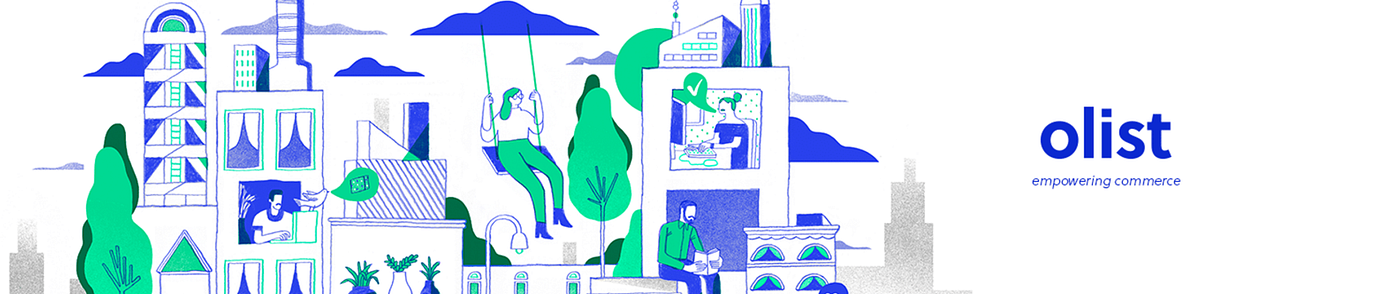

Namun, di balik tingginya volume transaksi yang mendongkrak *Gross Merchandise Value* (GMV), terdapat tantangan dalam mempertahankan pelanggan dan memaksimalkan nilai transaksi dari pelanggan yang telah diperoleh. Strategi akuisisi pengguna baru memakan *Customer Acquisition Cost* (CAC) yang tinggi, dan secara teori, biaya akuisisi ini bisa 5 hingga 25 kali lipat lebih mahal dibandingkan mempertahankan pelanggan lama (Harvard Business Review, 2014). Tingginya CAC menjadi tidak efisien jika pengguna berujung *churn* setelah satu kali transaksi.

Data transaksi Olist di tahun 2016–2018 menunjukkan adanya perbedaan skor ulasan pelanggan yang mengalami keterlambatan dan yang tepat waktu (Brazilian E-Commerce Public Dataset by Olist, 2018). Berdasarkan riset industri, 84% konsumen enggan berbelanja kembali setelah mengalami satu kali saja pengiriman yang buruk (Convey, 2021). Sebuah studi yang menggunakan dataset yang sama dengan yang digunakan pada proyek ini (Praxedes & Oliveira Filho, 2025) telah membuktikan secara statistik bahwa keterlambatan pengiriman berdampak signifikan terhadap penurunan skor ulasan pelanggan. Studi tersebut juga merujuk pada SERVQUAL (Parasuraman, Zeithaml & Berry, 1988), yang menempatkan ketepatan waktu sebagai salah satu faktor utama dalam persepsi pelanggan terhadap kualitas layanan.

Untuk mempertahankan sekaligus meningkatkan GMV, Olist perlu menjaga retensi pelanggan dan memastikan performa logistik tetap baik, karena pengalaman pengiriman dapat berkaitan dengan keputusan pelanggan untuk melakukan pembelian kembali. Proyek ini menelusuri rantai tersebut secara menyeluruh: mulai dari akar masalah operasional, dampaknya terhadap kepuasan dan pola pembelian berulang, hingga skala nilai bisnis (GMV) yang terkait.

## DAFTAR ISI

**Business Understanding**

- [Latar Belakang](#scrollTo=81d610b0)
- [Pernyataan Masalah](#scrollTo=50ddee66)
- [Pemangku Kepentingan (Stakeholders)](#scrollTo=56372360)
- [Tujuan Analisis](#scrollTo=a66a0aca)

**Data & Persiapan**

- [Data](#scrollTo=33ba31db)
- [Skema Database](#scrollTo=quA51nRCh0vv)
- [Data Understanding and Cleaning](#scrollTo=8a138203)
  - [1. Pengecekan Data Duplikat](#scrollTo=519fdb4d)
  - [2. Penanganan Missing Value](#scrollTo=9c3e2841)
  - [3. Standarisasi Tipe Data Tanggal](#scrollTo=7b8f4960)
  - [4. Penyaringan Status Pesanan & Missing Timestamp Krusial](#scrollTo=7f5e1848)
  - [5. Penanganan Anomali Kronologi Waktu](#scrollTo=eeec2d51)
  - [6. Agregasi Sebelum Penggabungan](#scrollTo=8fb75cad)
  - [7. Pengecekan Outlier](#scrollTo=81e538b3)
- [Data yang Sudah Bersih (Feature Engineering)](#scrollTo=83224998)

**Data Analysis**

- [Sesi 1: Dampak Keterlambatan terhadap Kepuasan Pelanggan](#scrollTo=4fb2be8f)
  - [Uji Hipotesis Sesi 1](#scrollTo=087f1286)
  - [Sesi 1 (Lanjutan): Analisis Teks Ulasan — Word Count, Bi-Gram & Sentimen](#scrollTo=02c3916c)
- [Sesi 2: Pemetaan Akar Masalah Logistik per Wilayah & Seller](#scrollTo=651dc820)
  - [Uji Hipotesis Sesi 2](#scrollTo=f3ff7810)
- [Sesi 3: Analisis GMV & Retensi Pelanggan (Cohort Analysis)](#scrollTo=76ce2054)
  - [Uji Hipotesis Sesi 3](#scrollTo=c8bad547)
- [Sesi 4: Tren Bulanan & Deteksi Periode Krisis Logistik](#scrollTo=3dc9df26)

**Penutup & Rencana Bisnis**

- [Kesimpulan](#scrollTo=ba0de7d0)
- [Rekomendasi, Target SMART & Ringkasan Eksekusi per Stakeholder](#scrollTo=be3e000b)
- [Cost-Benefit Analysis — Estimasi Dampak Bisnis](#scrollTo=f96fc4fe)

## Pernyataan Masalah (Problem Statement)

**Masalah Utama:**
Penurunan ketepatan waktu pengiriman berdampak pada kepuasan pelanggan, yang menyebabkan terhentinya pola pembelian berulang dan berimbas pada hilangnya potensi nilai bisnis (GMV).

#

Sebagai *data analyst*, kita akan membedah masalah utama di atas menjadi beberapa **masalah turunan** berikut. Setiap masalah turunan dipetakan satu-ke-satu dengan tujuan proyek:

1. Seberapa signifikan dampak keterlambatan pengiriman (*SLA miss*) terhadap anjloknya skor ulasan pelanggan, dan keluhan apa yang paling dominan disuarakan pelanggan di dalam teks ulasannya?
2. Di titik mana (*seller* atau wilayah geografis) *bottleneck* logistik paling dominan terjadi: apakah murni karena performa kurir di wilayah tertentu (*carrier delay*), atau akibat keterlambatan penjual UMKM saat memproses pesanan (*seller delay*)?
3. Berapa besar selisih kontribusi nilai bisnis (GMV) antara basis pelanggan satu kali (*one-time buyer*) dibandingkan dengan kelompok pelanggan loyal (*repeat buyer*), dan seberapa besar pengalaman keterlambatan menutup peluang pelanggan untuk kembali berbelanja (*repeat order*)?
4. Kapan keterlambatan paling meningkat, dan apakah terdapat periode tertentu dengan late rate yang lebih tinggi dibandingkan rata-rata?

## Pemangku Kepentingan (Stakeholders)

Temuan dan rekomendasi dari analisis ini akan digunakan secara langsung oleh pihak-pihak berikut:

1. **VP Operations & Logistics (Main Stakeholder):** Pengambil keputusan utama untuk mengevaluasi mitra ekspedisi dan memprioritaskan perbaikan infrastruktur pengiriman.
2. **Head of Customer Experience (CX):** Merancang pedoman kompensasi (seperti *voucher* diskon) secara proaktif ketika suatu pesanan terdeteksi akan mengalami keterlambatan, guna mencegah anjloknya skor ulasan.
3. **Seller Management:** Memberikan teguran atau edukasi operasional kepada UMKM yang secara konsisten memiliki angka *seller delay* tertinggi.
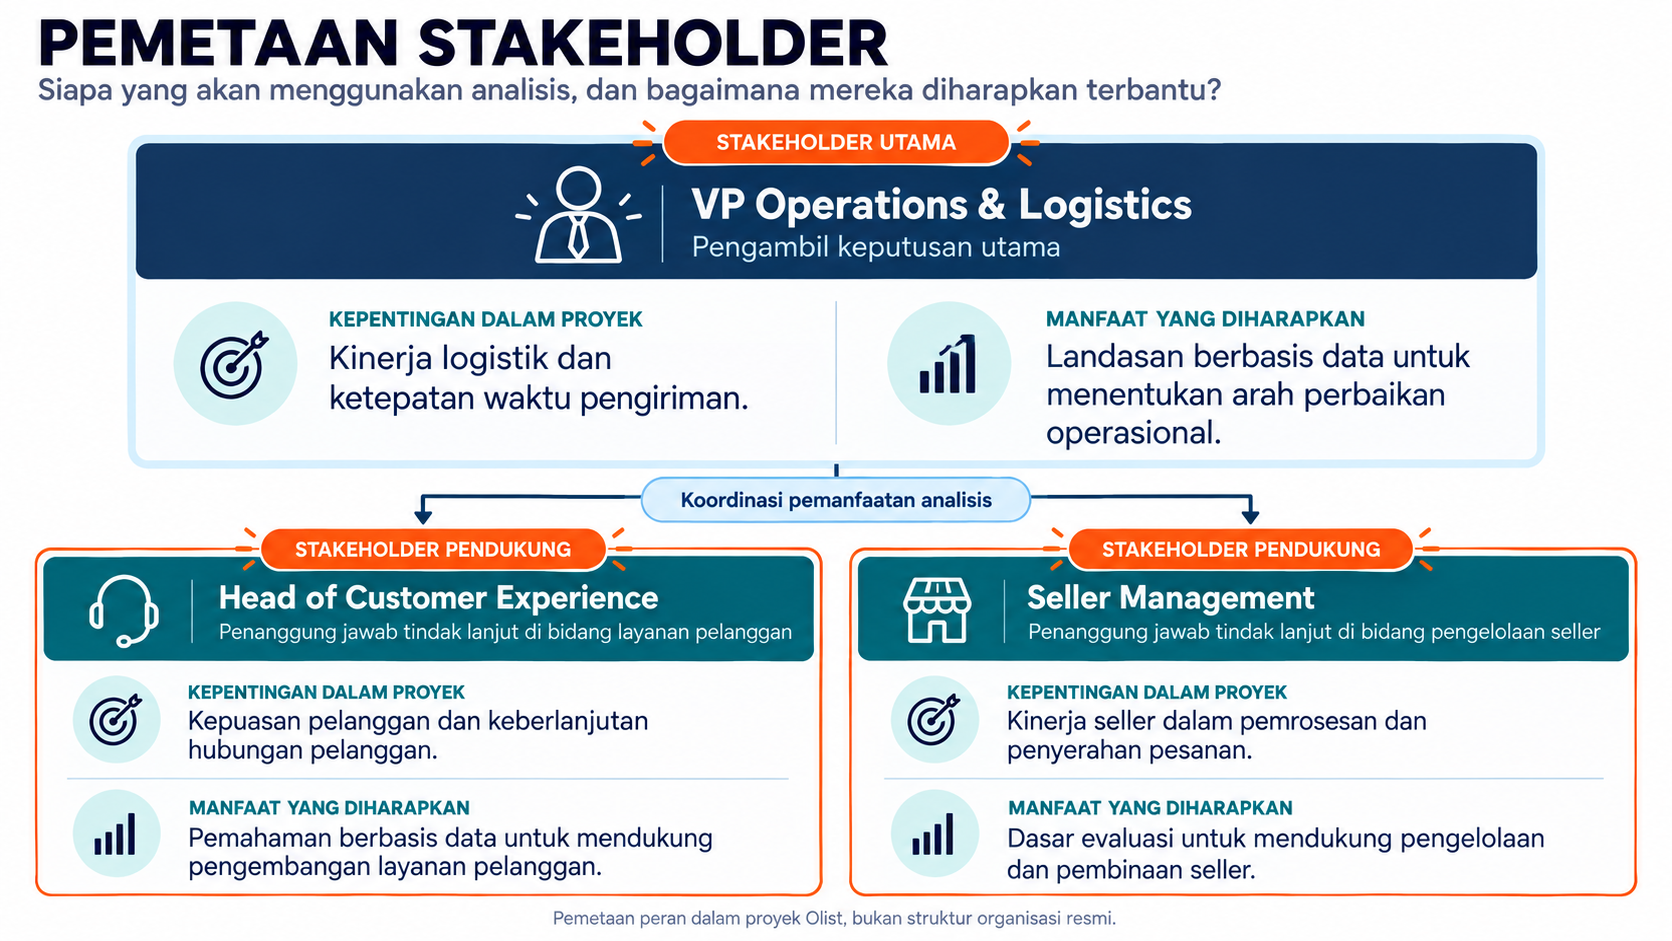


## Tujuan (Goals)

Setiap tujuan di bawah ini dirancang untuk menjawab. Jika analisis ini berhasil dieksekusi dengan baik, target terukur yang akan dicapai adalah:

1. **Kuantifikasi Dampak Keterlambatan terhadap Kepuasan:** Mengukur dan memvalidasi secara statistik besarnya penurunan skor ulasan akibat *SLA miss*, serta mengidentifikasi tema keluhan dominan dari teks ulasan (*word count* single word & bi-gram, analisis sentimen) sebagai dasar prioritas perbaikan *Customer Experience*.
2. **Perbaikan Kualitas Logistik:** Memetakan wilayah bermasalah dan memisahkan persentase tanggung jawab *delay* (*seller* vs ekspedisi) untuk memprioritaskan perbaikan operasional. Target awal proyek ini adalah menekan tingkat keterlambatan minimal 15% (sebagai proksi target operasional yang divalidasi setelah *baseline* keterlambatan ditemukan pada tahap eksplorasi data).
3. **Peningkatan Retensi Pelanggan & Validasi Strategi GMV:** Mengukur secara kuantitatif dominasi GMV dari *cohort* pelanggan berulang beserta kaitan keterlambatan dengan kegagalan *repeat order*, untuk memvalidasi urgensi pergeseran strategi Olist dari sekadar akuisisi (*growth-driven*) menuju retensi (*profitability-driven*). Target: mendongkrak metrik *repeat order* sebesar 5%, merujuk pada *sweet spot* literatur Harvard Business Review (2014) yang membuktikan secara empiris bahwa kenaikan retensi 5% mampu mendongkrak profitabilitas perusahaan hingga 25–95% melalui efisiensi *Customer Acquisition Cost* (CAC).
4. **Analisis Tren dan Periode Risiko Logistik:** Mengidentifikasi pola bulanan late rate dan volume pesanan untuk menemukan periode dengan risiko keterlambatan tinggi sebagai dasar monitoring dan perencanaan kapasitas logistik.

Rincian operasional target di atas — lengkap dengan **perhitungan data internal, dukungan data sekunder, penerapan metode SMART, dan *cost-benefit analysis* dampak bisnis** — diuraikan pada bagian **Rekomendasi** di akhir notebook.

## Data

Analisis ini menggunakan data primer dari **[Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)** (Kaggle), periode **September 2016 – Oktober 2018**.

Berbeda dengan dataset satu-file, data Olist berbentuk **skema relasional 9 tabel** yang saling terhubung lewat *key*. Berikut *data dictionary* tabel utama beserta kunci relasinya:

**1. `olist_customers_dataset.csv` (Dimensi Pelanggan)**
- `customer_id`: ID unik untuk setiap sesi pesanan **(penghubung ke tabel *Orders*)**.
- `customer_unique_id`:ID pengenal pelanggan unik (krusial untuk melacak *repeat order* dan *cohort*).
- `customer_city` & `customer_state`: Lokasi geografis domisili pelanggan **(basis analisis spasial wilayah *bottleneck* logistik)**.

**2. `olist_orders_dataset.csv` (Fakta Pesanan Utama)**
- `order_id`: ID unik transaksi **(penghubung utama ke tabel *Order Items* & *Reviews*)**.
- `customer_id`: ID pengguna yang bertransaksi **(penghubung dari tabel *Customers*)**.
- `order_status`: Status pesanan (analisis mutlak difokuskan pada pesanan *delivered*).
- `order_purchase_timestamp`: Tanggal dan waktu transaksi dilakukan.
- `order_delivered_carrier_date`: Waktu aktual penjual menyerahkan barang ke kurir.
- `order_delivered_customer_date`: Waktu aktual barang sampai ke tangan konsumen.
- `order_estimated_delivery_date`: Estimasi batas waktu tiba atau *Service Level Agreement* (SLA).

**3. `olist_order_items_dataset.csv` (Detail Finansial & Item)**
- `order_id`: ID transaksi yang dikaitkan **(penghubung dari tabel *Orders*)**.
- `seller_id`: ID unik penjual/UMKM **(basis evaluasi performa *seller delay*)**.
- `shipping_limit_date`: Batas waktu maksimal penjual harus menyerahkan barang ke kurir.
- `price`: Nominal harga barang (basis perhitungan GMV).

**4. `olist_order_reviews_dataset.csv` (Ulasan Pelanggan)**
- `review_id`: ID unik ulasan.
- `order_id`: ID transaksi yang diulas **(penghubung dari tabel *Orders*)**.
- `review_score`: Skor kepuasan pelanggan terhadap pesanan (skala 1–5).

Tabel pendukung lain (`payments`, `products`, `sellers`, `geolocation`, `category_translation`) dimuat untuk pemeriksaan integritas, namun tidak semuanya masuk ke tabel analisis utama sesuai *scope*.

**Batasan Penelitian (Scope):**
- **Cakupan Waktu:** Rekam jejak historis September 2016 – Oktober 2018; analisis bersifat retrospektif.
- **Pemetaan Geografis:** Difokuskan pada tingkat negara bagian tujuan (`customer_state`) untuk pola makro distribusi, tanpa perhitungan jarak berbasis koordinat *latitude/longitude* yang rawan anomali pencatatan.
- **Validitas Pendapatan (GMV):** Dihitung murni dari nominal harga barang (`price`) secara eksklusif pada pesanan berstatus **delivered**. Ongkos kirim (`freight_value`) tidak dimasukkan ke porsi pendapatan.
- **Identifikasi Pelanggan:** Pelacakan *cohort* dan *repeat order* mutlak menggunakan `customer_unique_id`, bukan ID sesi `customer_id`, guna mencegah distorsi perhitungan *churn rate* menjadi 100%.
- **Asumsi Pesanan Multi-Item:** Jika satu keranjang berisi beberapa barang dari penjual berbeda dengan `shipping_limit_date` berbeda, sistem diagregasi menggunakan nilai maksimum (*max*). Keterlambatan satu item dianggap sebagai pelanggaran waktu (*SLA breach*) bagi keseluruhan pesanan di mata konsumen.

### Skema Database (Relasi Antar Tabel & Primary Key)

Diagram di bawah memvisualisasikan relasi ke-9 tabel Olist beserta *primary key* (**[PK]**) dan *foreign key* (**[FK]**) masing-masing. Tabel `olist_orders` menjadi pusat skema (*fact table*) yang terhubung ke dimensi pelanggan, detail item/finansial, ulasan, dan pembayaran. Tabel `olist_geolocation` ditampilkan demi kelengkapan skema, namun berada di luar *scope* analisis (lihat Batasan Penelitian di atas).
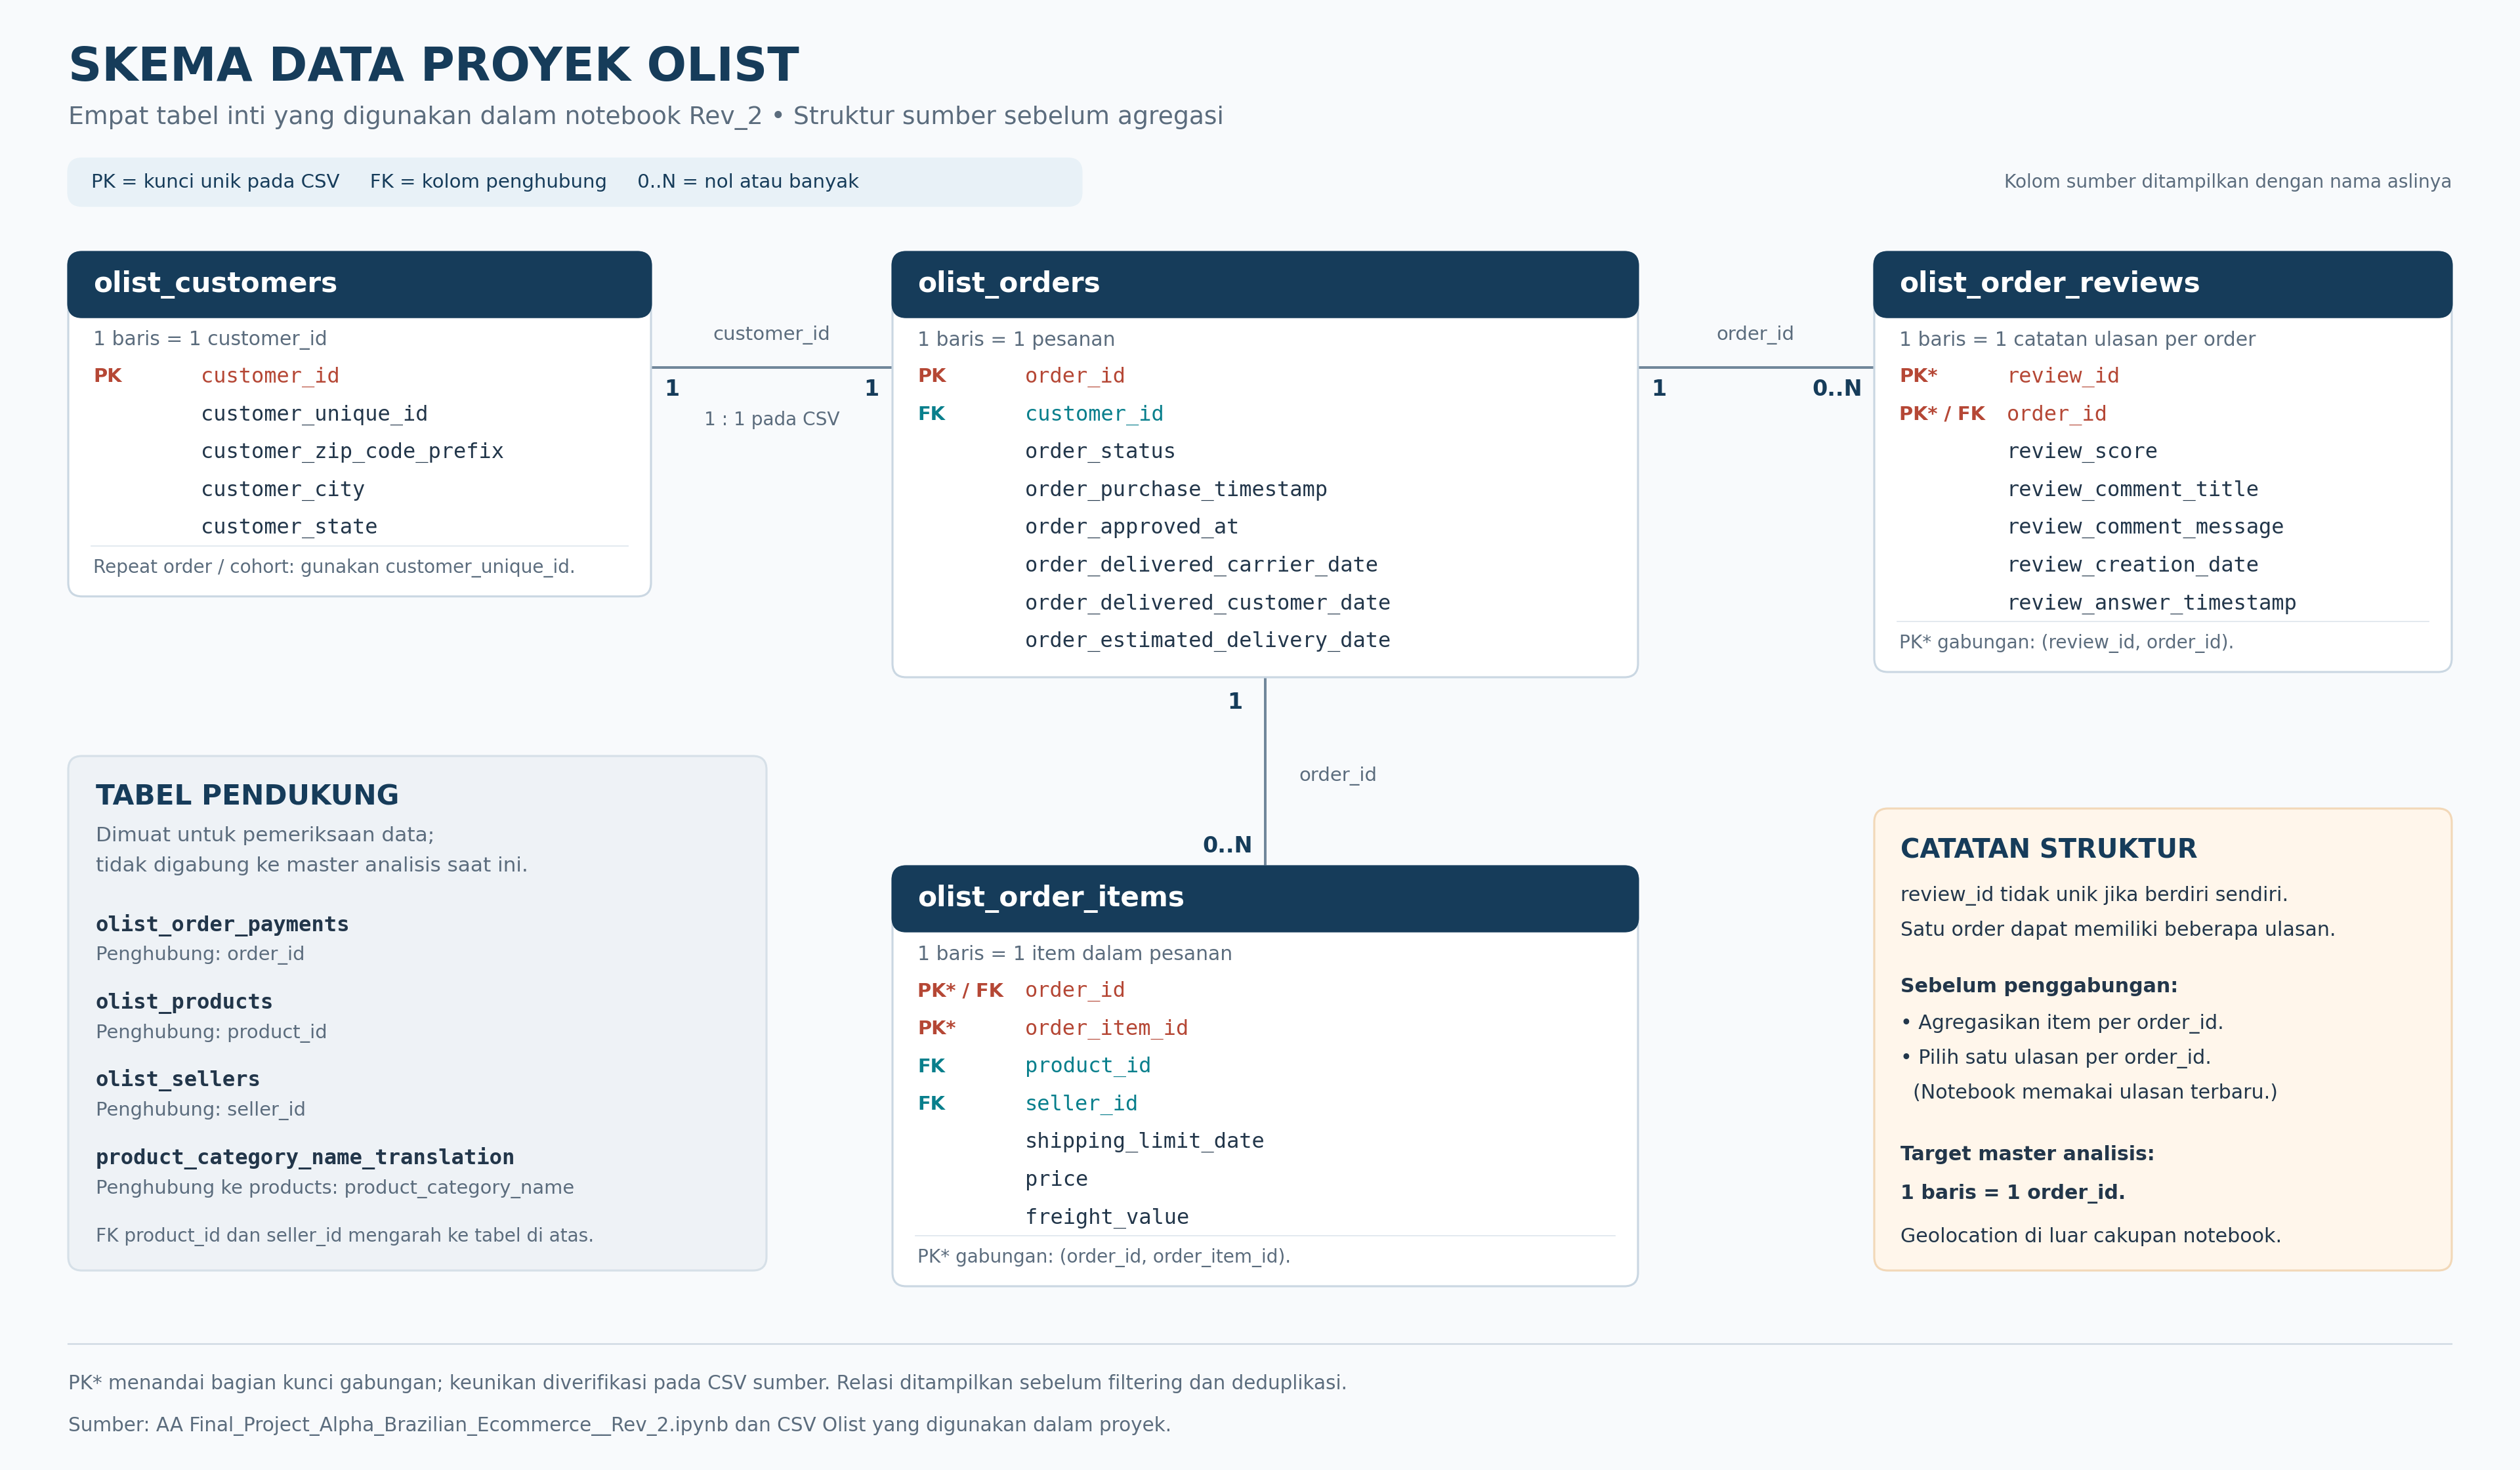

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 90

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

DATA_DIR = "/content/drive/MyDrive/Final Project Alpha/Dataset Olist"

def load(name):
    return pd.read_csv(os.path.join(DATA_DIR, name))

df_customers    = load("olist_customers_dataset.csv")
df_orders       = load("olist_orders_dataset.csv")
df_order_items  = load("olist_order_items_dataset.csv")
df_reviews      = load("olist_order_reviews_dataset.csv")
df_payments     = load("olist_order_payments_dataset.csv")
df_products     = load("olist_products_dataset.csv")
df_sellers      = load("olist_sellers_dataset.csv")
df_translation  = load("product_category_name_translation.csv")

raw_tables = {
    "customers": df_customers,
    "orders": df_orders,
    "order_items": df_order_items,
    "order_reviews": df_reviews,
    "order_payments": df_payments,
    "products": df_products,
    "sellers": df_sellers,
    "translations": df_translation,
}

# Menampilkan 5 baris teratas tabel-tabel inti analisis
print("Tabel Orders:")
display(df_orders.head())

print("\nTabel Order Items:")
display(df_order_items.head())

print("\nTabel Reviews:")
display(df_reviews.head())

print("\nTabel Customers:")
display(df_customers.head())

Tabel Orders:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



Tabel Order Items:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



Tabel Reviews:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53



Tabel Customers:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


## Data Understanding and Cleaning

Sebelum masuk ke dalam analisis, kita perlu mengenal dataset lebih jauh dalam tahapan *data understanding*. Dari proses ini, kita akan tahu anomali-anomali apa saja yang terdapat di dalam dataset dan perlu ditangani dalam tahapan *data cleaning*. Setiap penanganan anomali akan disertai justifikasi langkah yang diambil, baik secara *domain knowledge* maupun secara statistik.

Ada satu karakteristik penting yang membedakan proyek ini: **data Olist tidak bisa langsung digabungkan menjadi satu file datar (*flat file*)**. Relasi `orders → order_items` dan `orders → reviews` bersifat *one-to-many* (satu pesanan bisa punya banyak item dan lebih dari satu ulasan). Jika di-*merge* mentah-mentah, satu pesanan akan terduplikasi menjadi banyak baris sehingga nilai GMV dan jumlah pesanan menggelembung (*fan-out / row explosion*). Masalah ini kita tangani secara khusus di **tahap 6 (Penanganan Struktur Relasional)**.

Pertama, mari kita lihat informasi umum dari tabel-tabel yang dimuat.

In [ ]:
# Ringkasan dimensi setiap tabel
jumlah_baris = []
jumlah_kolom = []
for t in raw_tables.values():
    jumlah_baris.append(t.shape[0])
    jumlah_kolom.append(t.shape[1])

summary = pd.DataFrame({
    "tabel": list(raw_tables.keys()),
    "jumlah_baris": jumlah_baris,
    "jumlah_kolom": jumlah_kolom,
})
display(summary)

print("\nInfo Tabel Orders:")
df_orders.info()

,tabel,jumlah_baris,jumlah_kolom
0,customers,99441,5
1,orders,99441,8
2,order_items,112650,7
3,order_reviews,99224,7
4,order_payments,103886,5
5,products,32951,9
6,sellers,3095,4
7,translations,71,2



Info Tabel Orders:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
# Detail summarize seluruh tabel: tipe data, missing, kardinalitas, dan contoh nilai
def detail_summarize(df_, nama):
    contoh = []
    for k in df_.columns:
        if df_[k].notna().any():
            contoh.append(str(df_[k].dropna().iloc[0])[:45])
        else:
            contoh.append('-')

    ringkas = pd.DataFrame({
        'kolom': df_.columns,
        'tipe_data': df_.dtypes.astype(str).values,
        'non_null': df_.notna().sum().values,
        'jumlah_missing': df_.isna().sum().values,
        'pct_missing': (df_.isna().mean() * 100).round(2).values,
        'nilai_unik': df_.nunique().values,
        'contoh_nilai': contoh,
    })
    print(f"=== Detail Summarize: {nama}  ({df_.shape[0]:,} baris × {df_.shape[1]} kolom | duplikat baris utuh: {df_.duplicated().sum():,}) ===")
    display(ringkas)

for nama, tabel in raw_tables.items():
    detail_summarize(tabel, nama)

=== Detail Summarize: customers  (99,441 baris × 5 kolom | duplikat baris utuh: 0) ===


,kolom,tipe_data,non_null,jumlah_missing,pct_missing,nilai_unik,contoh_nilai
0,customer_id,object,99441,0,0.0,99441,06b8999e2fba1a1fbc88172c00ba8bc7
1,customer_unique_id,object,99441,0,0.0,96096,861eff4711a542e4b93843c6dd7febb0
2,customer_zip_code_prefix,int64,99441,0,0.0,14994,14409
3,customer_city,object,99441,0,0.0,4119,franca
4,customer_state,object,99441,0,0.0,27,SP


=== Detail Summarize: orders  (99,441 baris × 8 kolom | duplikat baris utuh: 0) ===


,kolom,tipe_data,non_null,jumlah_missing,pct_missing,nilai_unik,contoh_nilai
0,order_id,object,99441,0,0.00,99441,e481f51cbdc54678b7cc49136f2d6af7
1,customer_id,object,99441,0,0.00,99441,9ef432eb6251297304e76186b10a928d
2,order_status,object,99441,0,0.00,8,delivered
3,order_purchase_timestamp,object,99441,0,0.00,98875,2017-10-02 10:56:33
4,order_approved_at,object,99281,160,0.16,90733,2017-10-02 11:07:15
5,order_delivered_carrier_date,object,97658,1783,1.79,81018,2017-10-04 19:55:00
6,order_delivered_customer_date,object,96476,2965,2.98,95664,2017-10-10 21:25:13
7,order_estimated_delivery_date,object,99441,0,0.00,459,2017-10-18 00:00:00


=== Detail Summarize: order_items  (112,650 baris × 7 kolom | duplikat baris utuh: 0) ===


...

,kolom,tipe_data,non_null,jumlah_missing,pct_missing,nilai_unik,contoh_nilai
0,product_id,object,32951,0,0.00,32951,1e9e8ef04dbcff4541ed26657ea517e5
1,product_category_name,object,32341,610,1.85,73,perfumaria
2,product_name_lenght,float64,32341,610,1.85,66,40.0
3,product_description_lenght,float64,32341,610,1.85,2960,287.0
4,product_photos_qty,float64,32341,610,1.85,19,1.0
5,product_weight_g,float64,32949,2,0.01,2204,225.0
6,product_length_cm,float64,32949,2,0.01,99,16.0
7,product_height_cm,float64,32949,2,0.01,102,10.0
8,product_width_cm,float64,32949,2,0.01,95,14.0


=== Detail Summarize: sellers  (3,095 baris × 4 kolom | duplikat baris utuh: 0) ===


,kolom,tipe_data,non_null,jumlah_missing,pct_missing,nilai_unik,contoh_nilai
0,seller_id,object,3095,0,0.0,3095,3442f8959a84dea7ee197c632cb2df15
1,seller_zip_code_prefix,int64,3095,0,0.0,2246,13023
2,seller_city,object,3095,0,0.0,611,campinas
3,seller_state,object,3095,0,0.0,23,SP


=== Detail Summarize: translations  (71 baris × 2 kolom | duplikat baris utuh: 0) ===


,kolom,tipe_data,non_null,jumlah_missing,pct_missing,nilai_unik,contoh_nilai
0,product_category_name,object,71,0,0.0,71,beleza_saude
1,product_category_name_english,object,71,0,0.0,71,health_beauty


Dari *detail summarize* di atas, karakteristik penting setiap tabel dapat dirangkum sebagai berikut:

- **Kunci relasi sehat:** `order_id` unik sebanyak 99.441 di tabel `orders` (1 baris = 1 pesanan) dan `customer_id` unik penuh di `customers` — tidak ada duplikat *primary key*. Sebaliknya, `order_id` di `order_items` (112.650 baris untuk 98.666 pesanan) dan di `order_reviews` (99.224 baris untuk 98.673 pesanan) memang berulang — bukti relasi *one-to-many* yang wajib diagregasi/dideduplikasi sebelum penggabungan (ditangani di tahap 6).
- **Indikasi repeat order:** `customer_unique_id` hanya memiliki **96.096 nilai unik** dari 99.441 baris `customers`. Selisih ±3.345 ini menandakan ada pelanggan yang bertransaksi lebih dari satu kali (setiap pesanan membuat `customer_id` sesi baru) — inilah alasan *scope* mewajibkan pelacakan retensi memakai `customer_unique_id`.
- **Missing value terkonsentrasi & dapat dijelaskan:** kolom-kolom *timestamp* pengiriman di `orders` (dibedah tuntas pada tahap Missing Value), kolom teks ulasan `review_comment_title` (±88%) dan `review_comment_message` (±59%) yang memang opsional bagi pelanggan, serta 610 produk tanpa kategori — seluruhnya tidak menyentuh kolom kunci analisis.
- **Seluruh kolom tanggal masih bertipe `object` (string)** di semua tabel dan wajib dikonversi ke `datetime` (ditangani di tahap 3).

In [ ]:
# Distribusi status pesanan — dasar penyaringan populasi analisis
status_counts = df_orders['order_status'].value_counts()
status_pct = (status_counts / len(df_orders) * 100).round(2)
display(pd.DataFrame({"jumlah": status_counts, "persen": status_pct}))

print("\nStatistik Deskriptif - Tabel Order Items (kolom numerik):")
display(df_order_items[['price', 'freight_value']].describe())

print("\nStatistik Deskriptif - Tabel Reviews:")
display(df_reviews[['review_score']].describe())

,jumlah,persen
order_status,,
delivered,96478,97.02
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00



Statistik Deskriptif - Tabel Order Items (kolom numerik):


,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000



Statistik Deskriptif - Tabel Reviews:


,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


Dari ringkasan di atas, kita menemukan beberapa *insight* awal:

- Dataset `orders` memuat **99.441 pesanan**, dan mayoritas mutlak (**96.478 pesanan atau 97,02%**) berstatus `delivered`. Status lain (shipped, canceled, unavailable, dll.) jumlahnya kecil dan **tidak relevan** untuk kalkulasi durasi pengiriman akhir maupun GMV — sesuai *scope*, analisis difokuskan pada pesanan `delivered`.
- Kolom `price` memiliki rentang sangat lebar (R$ 0,85 hingga R$ 6.735) — wajar untuk *marketplace* multi-kategori, sehingga nilai tinggi **tidak otomatis dianggap outlier fraud**, melainkan variasi harga produk riil.
- `review_score` sudah berada di rentang valid 1–5 tanpa nilai di luar skala.
- Seluruh kolom tanggal masih bertipe `object` (string) dan harus dikonversi ke `datetime` agar bisa dihitung selisih harinya.

### 1. Pengecekan Data Duplikat

In [ ]:
# 1a. Memeriksa duplikat baris utuh pada masing-masing dataset
print("=== Pengecekan Duplikat Baris Utuh ===")
for name, t in raw_tables.items():
    print(f"Total duplikat di {name:15s}: {t.duplicated().sum()} baris")

# 1b. Duplikat pada level KUNCI (lebih krusial untuk merge)
print("\n=== Pengecekan Duplikat pada Level Kunci ===")
print(f"order_id duplikat di orders          : {df_orders['order_id'].duplicated().sum()}")
print(f"customer_id duplikat di customers    : {df_customers['customer_id'].duplicated().sum()}")
dup_review_orders = df_reviews['order_id'].duplicated().sum()
print(f"order_id yang punya >1 ulasan        : {dup_review_orders} baris ulasan ekstra")
multi_item_orders = (df_order_items.groupby('order_id').size() > 1).sum()
print(f"order_id dengan lebih dari 1 item    : {multi_item_orders} pesanan")

=== Pengecekan Duplikat Baris Utuh ===
Total duplikat di customers      : 0 baris
Total duplikat di orders         : 0 baris
Total duplikat di order_items    : 0 baris
Total duplikat di order_reviews  : 0 baris
Total duplikat di order_payments : 0 baris
Total duplikat di products       : 0 baris
Total duplikat di sellers        : 0 baris
Total duplikat di translations   : 0 baris

=== Pengecekan Duplikat pada Level Kunci ===
order_id duplikat di orders          : 0
customer_id duplikat di customers    : 0
order_id yang punya >1 ulasan        : 551 baris ulasan ekstra
order_id dengan lebih dari 1 item    : 9803 pesanan


Tidak ditemukan duplikat baris utuh maupun duplikat *primary key* pada `orders` dan `customers` — struktur kunci utama sehat.

Namun pada level relasi ditemukan dua sumber duplikasi yang **wajib** ditangani sebelum penggabungan:
1. **551 baris ulasan ekstra** — ada pesanan yang memiliki lebih dari satu ulasan. Jika dibiarkan, satu pesanan terhitung ganda dan membiaskan rata-rata kepuasan.
2. **Ribuan pesanan multi-item** — satu `order_id` muncul berkali-kali di tabel `order_items`. Jika di-*merge* langsung ke `orders`, baris pesanan menggandakan diri.

Keduanya adalah akar masalah "data tidak bisa digabung jadi satu file" dan akan diselesaikan lewat **deduplikasi ulasan** dan **agregasi item ke level pesanan** pada tahap 6.

### 2. Penanganan Missing Value

In [ ]:
# Persentase missing value di tabel-tabel inti
print("Persentase Missing Value - Tabel Orders:")
display((df_orders.isna().sum() / df_orders.shape[0] * 100).round(3))

print("\nPersentase Missing Value - Tabel Order Items:")
display((df_order_items.isna().sum() / df_order_items.shape[0] * 100).round(3))

print("\nPersentase Missing Value - Tabel Reviews:")
display((df_reviews.isna().sum() / df_reviews.shape[0] * 100).round(3))

Persentase Missing Value - Tabel Orders:


,0
order_id,0.000
customer_id,0.000
order_status,0.000
order_purchase_timestamp,0.000
order_approved_at,0.161
order_delivered_carrier_date,1.793
order_delivered_customer_date,2.982
order_estimated_delivery_date,0.000



Persentase Missing Value - Tabel Order Items:


,0
order_id,0.0
order_item_id,0.0
product_id,0.0
seller_id,0.0
shipping_limit_date,0.0
price,0.0
freight_value,0.0



Persentase Missing Value - Tabel Reviews:


,0
review_id,0.000
order_id,0.000
review_score,0.000
review_comment_title,88.342
review_comment_message,58.703
review_creation_date,0.000
review_answer_timestamp,0.000


Dari output persentase di atas, *missing value* di tabel-tabel inti hanya muncul pada tiga kolom *timestamp* tabel `orders` (`order_approved_at` 0,16%, `order_delivered_carrier_date` 1,79%, `order_delivered_customer_date` 2,98%) dan pada kolom teks ulasan yang memang opsional bagi pelanggan — sementara tabel `order_items` bersih 100% tanpa kekosongan. Persentase yang kecil ini **belum boleh langsung dihapus ataupun diimputasi**: kita perlu memastikan dulu **pola** kekosongannya lewat visualisasi sebaran dan *cross-check* terhadap status pesanan di bawah — apakah kekosongan tersebut acak (indikasi kerusakan data) atau justru konsekuensi logis dari status pesanan tertentu.

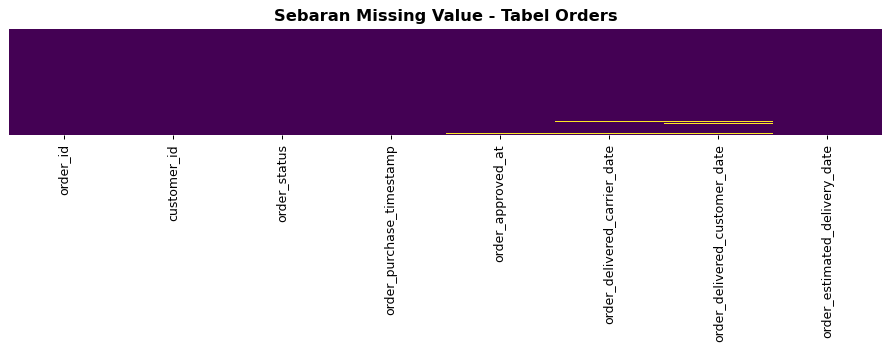

In [ ]:
# Sebaran missing value di tabel orders (visual)
plt.figure(figsize=(10, 4))
sns.heatmap(df_orders.isna(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Sebaran Missing Value - Tabel Orders', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Cross-check: missing timestamp vs status pesanan
kolom_dicek = ['order_delivered_carrier_date', 'order_delivered_customer_date']
missing_by_status = df_orders[kolom_dicek].isna().groupby(df_orders['order_status']).sum()
display(missing_by_status)

,order_delivered_carrier_date,order_delivered_customer_date
order_status,,
approved,2,2
canceled,550,619
created,5,5
delivered,2,8
invoiced,314,314
processing,301,301
shipped,0,1107
unavailable,609,609


Berdasarkan output persentase dan visualisasi di atas, sebaran *missing value* dapat dirangkum sebagai berikut:

- *Missing value* pada `order_delivered_carrier_date` (1,79%) dan `order_delivered_customer_date` (2,98%) hampir seluruhnya berasal dari pesanan **non-delivered** (canceled, shipped, unavailable) — ini **bukan kerusakan data**, melainkan konsekuensi logis: barang yang batal memang tidak pernah sampai.
- Yang benar-benar anomali hanyalah segelintir pesanan berstatus `delivered` namun kehilangan *timestamp* krusial: **8 pesanan** tanpa `order_delivered_customer_date` dan **2 pesanan** tanpa `order_delivered_carrier_date`. Baris ini akan dibuang karena status keterlambatannya mustahil dihitung akurat.
- Kolom `review_comment_title/message` banyak yang kosong — wajar (pelanggan sering hanya memberi bintang tanpa komentar) dan **tidak menjadi alasan menghapus skor ulasan**. Tanggal kosong juga tidak diisi dengan rata-rata atau estimasi buatan.

### 3. Standarisasi Tipe Data Tanggal (Datetime)

In [ ]:
# Mengubah seluruh kolom tanggal dari string/object menjadi datetime
date_cols_orders = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols_orders:
    df_orders[col] = pd.to_datetime(df_orders[col])

df_order_items['shipping_limit_date'] = pd.to_datetime(df_order_items['shipping_limit_date'])
df_reviews['review_creation_date'] = pd.to_datetime(df_reviews['review_creation_date'])
df_reviews['review_answer_timestamp'] = pd.to_datetime(df_reviews['review_answer_timestamp'])

print("Tipe data setelah konversi (orders):")
print(df_orders[date_cols_orders].dtypes)
print(f"\nRentang waktu transaksi: {df_orders['order_purchase_timestamp'].min()} s.d. {df_orders['order_purchase_timestamp'].max()}")

Tipe data setelah konversi (orders):
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Rentang waktu transaksi: 2016-09-04 21:15:19 s.d. 2018-10-17 17:30:18


### 4. Penyaringan Status Pesanan & Missing Timestamp Krusial

In [ ]:
rows_awal = len(df_orders)

# 4a. Hanya pesanan delivered (sesuai scope: durasi pengiriman & GMV)
df_delivered = df_orders[df_orders['order_status'] == 'delivered'].copy()
rows_delivered = len(df_delivered)

# 4b. Buang pesanan delivered yang kehilangan timestamp krusial
df_delivered = df_delivered.dropna(
    subset=['order_delivered_customer_date', 'order_delivered_carrier_date']
)
rows_bersih = len(df_delivered)

print(f"Pesanan awal (semua status)            : {rows_awal:,}")
print(f"Pesanan delivered                      : {rows_delivered:,}")
print(f"Delivered dgn timestamp lengkap        : {rows_bersih:,}")
print(f"Baris dibuang (missing timestamp)      : {rows_delivered - rows_bersih:,}")

Pesanan awal (semua status)            : 99,441
Pesanan delivered                      : 96,478
Delivered dgn timestamp lengkap        : 96,469
Baris dibuang (missing timestamp)      : 9


### 5. Penanganan Anomali Kronologi Waktu

In [ ]:
# Pesanan yang "sampai ke pelanggan" SEBELUM "diserahkan ke kurir" = mustahil secara logika
anomali_kronologi = df_delivered[
    df_delivered['order_delivered_customer_date'] < df_delivered['order_delivered_carrier_date']
]
print(f"Pesanan dengan kronologi mustahil (customer < carrier): {len(anomali_kronologi)} baris")
display(anomali_kronologi[
    ['order_id', 'order_delivered_carrier_date', 'order_delivered_customer_date']
].head())

# Buang anomali: durasi transit negatif akan meracuni atribusi seller vs kurir
df_delivered = df_delivered[
    df_delivered['order_delivered_customer_date'] >= df_delivered['order_delivered_carrier_date']
].copy()
print(f"\nJumlah pesanan setelah pembersihan kronologi: {len(df_delivered):,}")

Pesanan dengan kronologi mustahil (customer < carrier): 23 baris


,order_id,order_delivered_carrier_date,order_delivered_customer_date
6437,a1abeb653a4d4cd1e142ccb8c82cd069,2017-07-28 16:57:58,2017-07-25 19:32:56
9553,383aa8b2724fe452d9ccd9934a8c628b,2017-07-07 17:22:41,2017-07-06 14:27:51
13487,cb1134f9010d242e9515ad1c78ec0c39,2017-07-20 19:22:02,2017-07-19 14:13:28
14474,dceb62e8fa94b46006c9554fed743df0,2017-08-01 18:23:30,2017-07-26 18:09:10
19268,5f9d46795c3126674e52becb3a1a517f,2017-07-20 23:03:42,2017-07-20 18:52:41



Jumlah pesanan setelah pembersihan kronologi: 96,446


Ditemukan **23 pesanan** dengan pencatatan waktu mustahil (barang tercatat sampai ke pelanggan *sebelum* diserahkan ke kurir) — kemungkinan *bug* pencatatan sistem. Karena porsinya sangat kecil (0,02%) namun berpotensi merusak perhitungan atribusi *seller delay* vs *carrier delay* (durasi transit menjadi negatif), baris ini dibuang.

### 6. Penanganan Struktur Relasional (Agregasi Sebelum Penggabungan)

Inilah jawaban atas temuan bahwa **data tidak bisa digabungkan langsung menjadi satu file**. Strateginya: **turunkan semua tabel anak ke granularitas 1 baris = 1 `order_id` terlebih dahulu**, baru kemudian digabungkan. Aturannya:

1. **Ulasan** — jika satu `order_id` punya >1 ulasan, ambil hanya **ulasan dengan timestamp terbaru** (`review_answer_timestamp` maksimum) sebagai representasi penilaian final pelanggan, sesuai rencana *data cleaning* pada proposal.
2. **Item** — harga (`price`) **dijumlahkan** per pesanan menjadi GMV pesanan; `shipping_limit_date` diagregasi dengan **max** (keterlambatan satu item = pelanggaran SLA bagi keseluruhan pesanan di mata konsumen).
3. Seluruh penggabungan memakai **left join dari tabel orders** dengan parameter `validate=` agar pandas otomatis menggagalkan proses bila relasi tidak sesuai harapan (pengaman anti *row explosion*).

In [ ]:
# 6a. Deduplikasi ulasan: kalau satu order punya >1 ulasan, ambil yang timestamp-nya paling baru
print(f"Baris ulasan sebelum deduplikasi : {len(df_reviews):,}")

reviews_urut = df_reviews.sort_values(
    ['order_id', 'review_answer_timestamp', 'review_creation_date'],
    na_position='first', kind='stable'
)
reviews_dedup = reviews_urut.drop_duplicates(subset='order_id', keep='last')  # last = timestamp terbaru
reviews_dedup = reviews_dedup[['order_id', 'review_id', 'review_score', 'review_answer_timestamp']]

assert reviews_dedup['order_id'].is_unique, "Masih ada order_id ganda di tabel ulasan!"
print(f"Baris ulasan setelah deduplikasi : {len(reviews_dedup):,}")
print(f"Ulasan duplikat yang dieliminasi : {len(df_reviews) - len(reviews_dedup):,}")

Baris ulasan sebelum deduplikasi : 99,224
Baris ulasan setelah deduplikasi : 98,673
Ulasan duplikat yang dieliminasi : 551


In [ ]:
# 6b. Agregasi order_items ke level pesanan (1 baris = 1 order_id)
print(f"Baris order_items sebelum agregasi: {len(df_order_items):,}")

items_agg = df_order_items.groupby('order_id', as_index=False).agg(
    order_gmv=('price', 'sum'),                        # GMV = total harga item per pesanan
    freight_total=('freight_value', 'sum'),            # ongkir, di luar GMV (referensi saja)
    item_count=('order_item_id', 'count'),
    seller_count=('seller_id', 'nunique'),
    shipping_limit_max=('shipping_limit_date', 'max')  # multi-item: pakai max sesuai asumsi scope
)

assert items_agg['order_id'].is_unique, "Agregasi item gagal: order_id masih ganda!"
print(f"Baris setelah agregasi (1 baris = 1 pesanan): {len(items_agg):,}")
display(items_agg.head())

Baris order_items sebelum agregasi: 112,650
Baris setelah agregasi (1 baris = 1 pesanan): 98,666


,order_id,order_gmv,freight_total,item_count,seller_count,shipping_limit_max
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1,1,2017-09-19 09:45:35
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1,1,2017-05-03 11:05:13
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1,1,2018-01-18 14:48:30
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1,1,2018-08-15 10:10:18
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1,1,2017-02-13 13:57:51


In [ ]:
# 6c. Gabungkan semuanya jadi master table level pesanan (left join dari orders delivered)
df_master = df_delivered.merge(
    df_customers[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']],
    on='customer_id', how='left', validate='many_to_one'
)
df_master = df_master.merge(items_agg, on='order_id', how='left', validate='one_to_one')
df_master = df_master.merge(reviews_dedup[['order_id', 'review_score']],
                            on='order_id', how='left', validate='one_to_one')

# 6d. Validasi hasil merge: baris tidak boleh bertambah, GMV tidak boleh berubah
assert len(df_master) == len(df_delivered), "Jumlah baris berubah setelah merge (fan-out terdeteksi)!"
assert df_master['order_id'].is_unique, "order_id ganda di master table!"
assert df_master['customer_unique_id'].notna().all(), "Ada pesanan tanpa identitas pelanggan!"

gmv_sumber = df_order_items.loc[
    df_order_items['order_id'].isin(df_delivered['order_id']), 'price'
].sum()
gmv_master = df_master['order_gmv'].sum()
assert np.isclose(gmv_sumber, gmv_master, atol=0.01), "GMV berubah setelah merge!"

validasi = pd.DataFrame({
    'pemeriksaan': ['Jumlah pesanan delivered', 'GMV delivered (R$)', 'Pesanan tanpa ulasan', 'Pesanan tanpa item'],
    'nilai': [f"{len(df_master):,}", f"{gmv_master:,.2f}",
              f"{df_master['review_score'].isna().sum():,}",
              f"{df_master['order_gmv'].isna().sum():,}"]
})
print("=== Validasi Master Table ===")
display(validasi)

=== Validasi Master Table ===


,pemeriksaan,nilai
0,Jumlah pesanan delivered,"96,446"
1,GMV delivered (R$),"13,216,311.19"
2,Pesanan tanpa ulasan,646
3,Pesanan tanpa item,0


Master table berhasil dibangun **tanpa penggandaan baris dan tanpa distorsi GMV** (total GMV sebelum dan sesudah *merge* identik hingga 2 desimal — divalidasi otomatis lewat `assert`).

Catatan penanganan sisa *missing value*:
- **646 pesanan delivered tanpa ulasan (0,67%)** tetap dipertahankan untuk analisis logistik & GMV; skor ulasannya **tidak diisi nol** karena 0 bukan nilai valid pada skala 1–5. Baris ini hanya dikeluarkan otomatis saat analisis yang memang membutuhkan skor ulasan.
- Seluruh pesanan delivered memiliki catatan item, sehingga tidak ada kekosongan GMV.

### 7. Pengecekan Outlier

Sebelum master table dipakai untuk analisis, kolom numerik kunci diperiksa *outlier*-nya dengan metode **IQR (Interquartile Range)** — nilai di luar rentang $[Q1 - 1.5 \times IQR,\ Q3 + 1.5 \times IQR]$ ditandai sebagai *outlier* — disertai visual *boxplot*. Tujuan pengecekan ini **bukan otomatis membuang data**, melainkan memutuskan secara sadar dan terjustifikasi: apakah nilai ekstrem tersebut kesalahan data, atau variasi bisnis yang sah.

,kolom,Q1,median,Q3,batas_bawah_IQR,batas_atas_IQR,nilai_min,nilai_max,jumlah_outlier,pct_outlier
0,order_gmv,45.90,86.50,149.90,-110.10,305.90,0.85,13440.00,7657,7.94
1,freight_total,13.85,17.17,24.01,-1.39,39.25,0.00,1794.96,9695,10.05
2,item_count,1.00,1.00,1.00,1.00,1.00,1.00,21.00,9615,9.97
3,durasi_kirim_hari,6.00,10.00,15.00,-7.50,28.50,0.00,209.00,5021,5.21


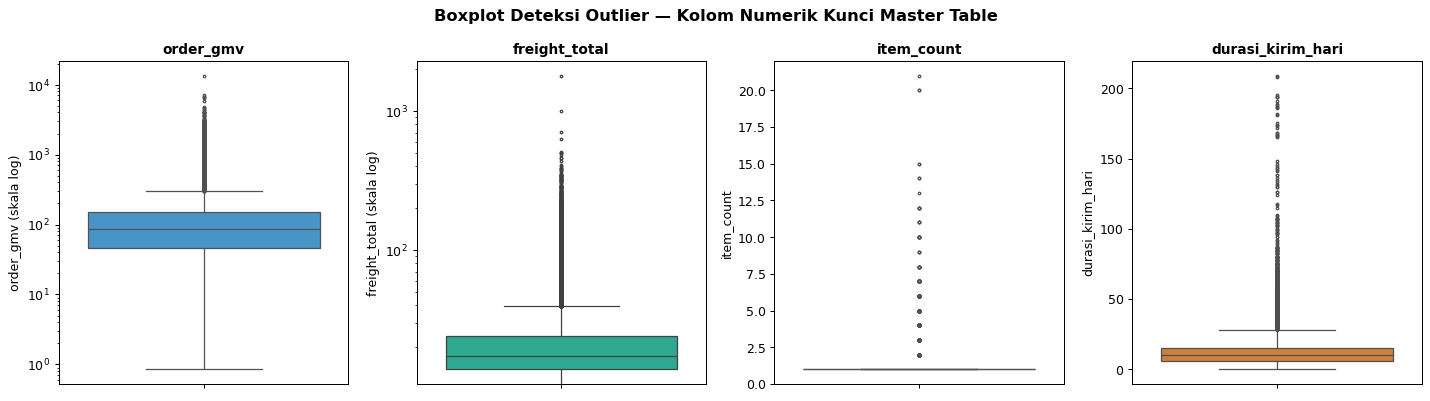

Kontribusi GMV dari pesanan di atas batas IQR (> R$ 305.90): R$ 4,841,537 (36.6% dari total GMV)


In [ ]:
# Cek outlier dengan metode IQR + boxplot.
# Durasi kirim dihitung sementara di sini; fitur resminya dibuat di tahap feature engineering.
df_cek = df_master.copy()
df_cek['durasi_kirim_hari'] = (
    df_cek['order_delivered_customer_date'] - df_cek['order_purchase_timestamp']
).dt.days

kolom_cek = ['order_gmv', 'freight_total', 'item_count', 'durasi_kirim_hari']
ringkasan_outlier = []
for kol in kolom_cek:
    s = df_cek[kol].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    batas_bawah, batas_atas = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((s < batas_bawah) | (s > batas_atas)).sum()
    ringkasan_outlier.append({
        'kolom': kol, 'Q1': round(q1, 2), 'median': round(s.median(), 2), 'Q3': round(q3, 2),
        'batas_bawah_IQR': round(batas_bawah, 2), 'batas_atas_IQR': round(batas_atas, 2),
        'nilai_min': round(s.min(), 2), 'nilai_max': round(s.max(), 2),
        'jumlah_outlier': int(n_out), 'pct_outlier': round(n_out / len(s) * 100, 2),
    })
display(pd.DataFrame(ringkasan_outlier))

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, kol, warna in zip(axes, kolom_cek, ['#3498db', '#1abc9c', '#9b59b6', '#e67e22']):
    sns.boxplot(y=df_cek[kol], ax=ax, color=warna, fliersize=2)
    ax.set_title(kol, fontsize=11, fontweight='bold')
    if kol in ('order_gmv', 'freight_total'):
        ax.set_yscale('log')   # pakai skala log biar sebaran harga tetap kebaca
        ax.set_ylabel(f'{kol} (skala log)')
plt.suptitle('Boxplot Deteksi Outlier — Kolom Numerik Kunci Master Table', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# seberapa besar sumbangan GMV dari pesanan "outlier" bernilai tinggi?
batas_gmv = df_cek['order_gmv'].quantile(0.75) + 1.5 * (df_cek['order_gmv'].quantile(0.75) - df_cek['order_gmv'].quantile(0.25))
gmv_outlier = df_cek.loc[df_cek['order_gmv'] > batas_gmv, 'order_gmv'].sum()
print(f"Kontribusi GMV dari pesanan di atas batas IQR (> R$ {batas_gmv:.2f}): "
      f"R$ {gmv_outlier:,.0f} ({gmv_outlier / df_cek['order_gmv'].sum() * 100:.1f}% dari total GMV)")

**Keputusan Penanganan Outlier**

Secara statistik, metode IQR menandai 5–10% baris sebagai *outlier* di setiap kolom. Namun setelah ditelaah, seluruhnya adalah **variasi bisnis yang sah — bukan kesalahan data — sehingga dipertahankan**, dengan justifikasi per kolom:

- **`order_gmv` (7,94% outlier; maks. R$ 13.440):** rentang harga lebar adalah hal wajar untuk *marketplace* multi-kategori (elektronik/furnitur vs aksesori murah). Justru pesanan "outlier" bernilai tinggi ini menyumbang **±36,6% dari total GMV** — membuangnya akan mendistorsi seluruh analisis GMV dan bertentangan dengan *scope* validitas pendapatan.
- **`freight_total` (10,05%) & `item_count` (9,97%):** ongkir tinggi mengikuti jarak dan berat kiriman (konsekuensi geografis Brasil), sedangkan `item_count` ditandai outlier semata-mata karena Q1 = median = Q3 = 1 item (mayoritas pesanan berisi satu barang) sehingga batas IQR menyempit menjadi 1 — bukan karena nilainya tidak masuk akal (maksimum hanya 21 item).
- **`durasi_kirim_hari` (5,21% outlier; maks. 209 hari):** durasi ekstrem justru merupakan **objek penelitian itu sendiri** — kasus keterlambatan parah yang ingin dipetakan. Membuangnya berarti menghapus fenomena yang sedang dianalisis.

Sebagai mitigasi tanpa membuang data: (1) analisis memakai agregat yang tidak sensitif terhadap outlier pada titik yang tepat (median, proporsi, kategori keterlambatan alih-alih besaran mentah), (2) ukuran sampel puluhan ribu baris menjaga uji statistik tetap *robust*, dan (3) anomali yang benar-benar mustahil secara logika (kronologi waktu terbalik) sudah dibuang terpisah di tahap 5.

## Data yang Sudah Bersih (Feature Engineering)

In [ ]:
# Feature engineering di atas master table yang sudah bersih

# 1. status keterlambatan (SLA miss): tiba melewati tanggal estimasi
#    (dibandingkan level TANGGAL karena estimated_delivery_date tercatat jam 00:00)
df_master['is_late'] = (
    df_master['order_delivered_customer_date'].dt.normalize()
    > df_master['order_estimated_delivery_date'].dt.normalize()
)

# 2. besaran keterlambatan & durasi pengiriman total
df_master['delay_days'] = (
    df_master['order_delivered_customer_date'].dt.normalize()
    - df_master['order_estimated_delivery_date'].dt.normalize()
).dt.days
df_master['delivery_duration_days'] = (
    df_master['order_delivered_customer_date'] - df_master['order_purchase_timestamp']
).dt.days

# 3. atribusi tanggung jawab keterlambatan:
#    seller_late  = penjual serah barang ke kurir melewati shipping_limit_date
#    carrier_slow = durasi transit aktual melebihi jatah transit (estimasi tiba - batas serah)
df_master['seller_late'] = (
    df_master['order_delivered_carrier_date'] > df_master['shipping_limit_max']
)
transit_aktual = df_master['order_delivered_customer_date'] - df_master['order_delivered_carrier_date']
transit_jatah  = df_master['order_estimated_delivery_date'] - df_master['shipping_limit_max']
df_master['carrier_slow'] = transit_aktual > transit_jatah

def kategori_delay(row):
    if not row['is_late']:
        return 'Tepat Waktu'
    if row['seller_late'] and row['carrier_slow']:
        return 'Keterlambatan Ganda'
    if row['seller_late']:
        return 'Keterlambatan Seller'
    return 'Keterlambatan Kurir'

df_master['delay_category'] = df_master.apply(kategori_delay, axis=1)

# 4. bulan transaksi (buat analisis tren & cohort)
df_master['order_month'] = df_master['order_purchase_timestamp'].dt.to_period('M')

print(f"Dimensi final master table: {df_master.shape}")
print(f"Baseline tingkat keterlambatan: {df_master['is_late'].mean()*100:.2f}%")
display(df_master[['order_id', 'customer_unique_id', 'customer_state', 'order_gmv',
                   'review_score', 'is_late', 'delay_days', 'delay_category']].head())

Dimensi final master table: (96446, 24)
Baseline tingkat keterlambatan: 6.77%


,order_id,customer_unique_id,customer_state,order_gmv,review_score,is_late,delay_days,delay_category
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,SP,29.99,4.0,False,-8,Tepat Waktu
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,BA,118.70,4.0,False,-6,Tepat Waktu
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,GO,159.90,5.0,False,-18,Tepat Waktu
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,RN,45.00,5.0,False,-13,Tepat Waktu
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,SP,19.90,5.0,False,-10,Tepat Waktu


# Data Analysis

Untuk menjawab ketiga masalah turunan (beserta tujuannya masing-masing) secara komprehensif, analisis memadukan pendekatan **deskriptif** (visualisasi), **statistik inferensial** (uji hipotesis), dan **text mining** dalam lima sesi.

Pengerjaan & presentasi bagian *Data Analysis* hingga *Rekomendasi* dibagi berurutan ke tiga anggota tim sesuai kolom **PIC** di bawah; dashboard Looker dikerjakan Faishal.

| Sesi | Fokus | Menjawab | Metode Deskriptif | Uji / Metode Analitik | PIC |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 1 | Dampak keterlambatan → kepuasan pelanggan | Masalah & Tujuan #1 | Bar chart skor ulasan | Independent T-Test | Ahan |
| 1 (Lanjutan) | Isi keluhan pelanggan pada teks ulasan | Masalah & Tujuan #1 | Bar chart frekuensi kata | Word count (single word & bi-gram), analisis sentimen | Ahan |
| 2 | Pemetaan bottleneck (wilayah & seller vs kurir) | Masalah & Tujuan #2 | Pie chart, horizontal bar | Chi-Square | Tondi |
| 3 | GMV & retensi pelanggan | Masalah & Tujuan #3 | Cohort heatmap, bar chart GMV | Chi-Square | Tondi |
| 4 (tambahan) | Tren bulanan & deteksi periode krisis | Pendukung Masalah & Tujuan #2 | Line chart | — | Emy |

Untuk bagian penutup: **Kesimpulan** dan **Rekomendasi (termasuk target SMART)** dipresentasikan oleh **Emy**, melanjutkan langsung dari Sesi 4.

### Sesi 1: Dampak Keterlambatan terhadap Kepuasan Pelanggan

Menjawab **Masalah Turunan #1 / Tujuan #1**: seberapa signifikan dampak keterlambatan pengiriman (*SLA miss*) terhadap anjloknya skor ulasan pelanggan.

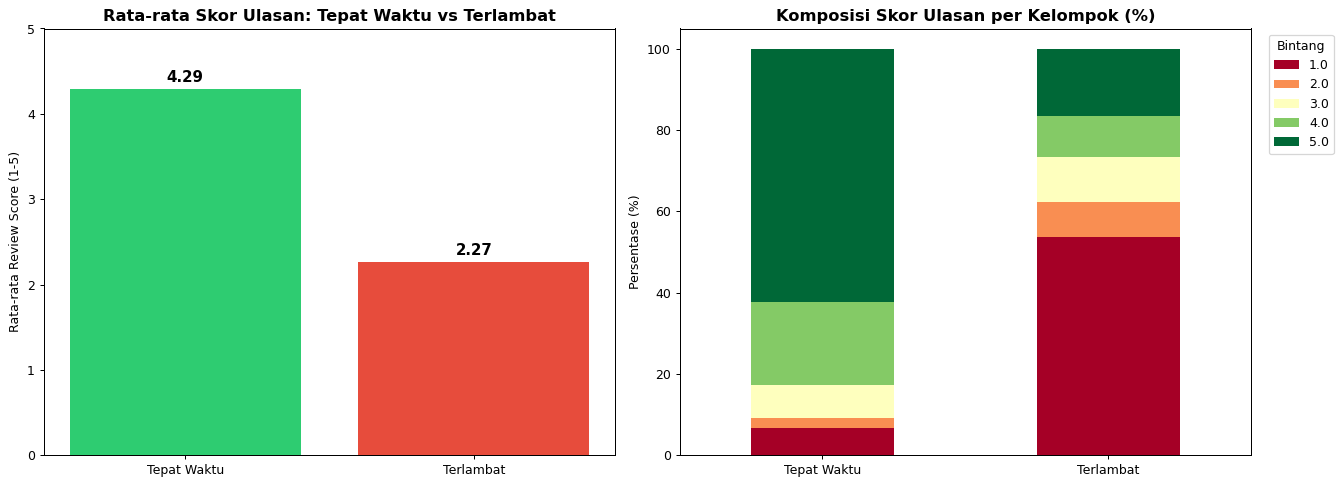

Proporsi ulasan bintang 1 | Terlambat  : 53.78%
Proporsi ulasan bintang 1 | Tepat Waktu: 6.61%
Rata-rata hari keterlambatan (saat terlambat): 10.6 hari


In [ ]:
# Populasi sesi ini: pesanan delivered yang MEMILIKI skor ulasan
df_review = df_master.dropna(subset=['review_score']).copy()
df_review['status_sla'] = np.where(df_review['is_late'], 'Terlambat', 'Tepat Waktu')

# Agregasi rata-rata skor & komposisi bintang per kelompok
avg_score = df_review.groupby('status_sla')['review_score'].mean()
dist_score = (
    pd.crosstab(df_review['status_sla'], df_review['review_score'], normalize='index') * 100
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# --- Grafik 1: Rata-rata skor ulasan Tepat Waktu vs Terlambat ---
colors = {'Tepat Waktu': '#2ecc71', 'Terlambat': '#e74c3c'}
warna_bar = []
for nama in avg_score.index:
    warna_bar.append(colors[nama])
bars = axes[0].bar(avg_score.index, avg_score.values, color=warna_bar)
axes[0].set_title('Rata-rata Skor Ulasan: Tepat Waktu vs Terlambat',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Rata-rata Review Score (1-5)')
axes[0].set_ylim(0, 5)
for b in bars:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.08,
                 f"{b.get_height():.2f}", ha='center', fontweight='bold', fontsize=12)

# --- Grafik 2: Komposisi bintang per kelompok (stacked) ---
dist_score.plot(kind='bar', stacked=True, colormap='RdYlGn', ax=axes[1], rot=0)
axes[1].set_title('Komposisi Skor Ulasan per Kelompok (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Persentase (%)')
axes[1].set_xlabel('')
axes[1].legend(title='Bintang', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

share_1star_late = (df_review.loc[df_review['is_late'], 'review_score'] == 1).mean() * 100
share_1star_ontime = (df_review.loc[~df_review['is_late'], 'review_score'] == 1).mean() * 100
print(f"Proporsi ulasan bintang 1 | Terlambat  : {share_1star_late:.2f}%")
print(f"Proporsi ulasan bintang 1 | Tepat Waktu: {share_1star_ontime:.2f}%")
print(f"Rata-rata hari keterlambatan (saat terlambat): {df_master.loc[df_master['is_late'], 'delay_days'].mean():.1f} hari")

**Insight & Temuan Kritis (Sesi 1)**
* **[Observasi]:** Keterlambatan pengiriman menghancurkan kepuasan pelanggan secara dramatis. Rata-rata skor ulasan anjlok dari **4,29** (tepat waktu) menjadi hanya **2,27** (terlambat) — selisih **2,02 poin** pada skala 5. Lebih ekstrem lagi, **53,8%** pesanan terlambat berujung ulasan **bintang 1**, dibandingkan hanya **6,6%** pada pesanan tepat waktu (hampir **8x lipat**). Rata-rata besaran keterlambatan pun parah: pesanan yang telat rata-rata meleset **±10,6 hari** dari estimasi — bukan keterlambatan tipis satu-dua hari.
* **[Hipotesis]:** Selisih 2 poin ini bukan fluktuasi acak, namun sesuai dengan teori SERVQUAL (Parasuraman et al., 1988) bahwa *reliability* (ketepatan waktu) adalah dimensi utama persepsi kualitas layanan. Konsisten dengan riset Convey (2021) yang menyatakan bahwa 84% konsumen enggan kembali setelah satu pengalaman pengiriman buruk, skor ulasan rendah ini adalah sinyal dini (*leading indicator*) *churn*.

Untuk memastikan selisih rata-rata skor (4,29 vs 2,27) signifikan secara statistik dan bukan kebetulan sampel, kita lakukan uji hipotesis.

### Uji Hipotesis Sesi 1 (Independent T-Test)

Karena kita membandingkan **rata-rata variabel numerik** (`review_score`) antara **dua kelompok independen** (Tepat Waktu vs Terlambat), uji yang tepat adalah **Independent Samples T-Test**. Digunakan varian **Welch's T-Test** (`equal_var=False`) karena ukuran dan varians kedua kelompok berbeda jauh.

**Rumusan Hipotesis:**
* $H_0$: Tidak ada perbedaan rata-rata skor ulasan yang signifikan antara pesanan tepat waktu dan pesanan terlambat.
* $H_1$: Terdapat perbedaan rata-rata skor ulasan yang signifikan antara pesanan tepat waktu dan pesanan terlambat.

Tingkat signifikansi ($\alpha$) ditetapkan sebesar **0.05**.

In [ ]:
from scipy.stats import ttest_ind

score_ontime = df_review.loc[~df_review['is_late'], 'review_score']
score_late   = df_review.loc[df_review['is_late'], 'review_score']

t_stat, p_val = ttest_ind(score_ontime, score_late, equal_var=False)

print(f"n Tepat Waktu : {len(score_ontime):,} pesanan (mean = {score_ontime.mean():.4f})")
print(f"n Terlambat   : {len(score_late):,} pesanan (mean = {score_late.mean():.4f})")
print("-" * 55)
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_val:.4e}")
print("-" * 55)

alpha = 0.05
print("\nKesimpulan Uji Statistik:")
if p_val < alpha:
    print("Tolak H0: Terdapat perbedaan skor ulasan yang signifikan antara pesanan tepat waktu dan terlambat.")
else:
    print("Gagal Tolak H0: Tidak terdapat perbedaan skor ulasan yang signifikan.")

n Tepat Waktu : 89,420 pesanan (mean = 4.2908)
n Terlambat   : 6,380 pesanan (mean = 2.2701)
-------------------------------------------------------
T-statistic : 100.8401
P-value     : 0.0000e+00
-------------------------------------------------------

Kesimpulan Uji Statistik:
Tolak H0: Terdapat perbedaan skor ulasan yang signifikan antara pesanan tepat waktu dan terlambat.


**Interpretasi & Validasi Hipotesis (Sesi 1):**

Diperoleh nilai **T-statistic ≈ 100,8** dengan **p-value ≈ 0.0000** ($p < 0.05$), sehingga kita **Menolak $H_0$**. Secara statistik terbukti definitif bahwa anjloknya skor ulasan pada pesanan terlambat **bukan kebetulan** (*random chance*), melainkan efek sistematis dari kegagalan SLA. Dengan ukuran sampel puluhan ribu pesanan dan selisih rata-rata 2,02 poin, efek ini tidak hanya signifikan secara statistik tetapi juga **sangat besar secara praktis** — memvalidasi dalil bisnis bahwa operasional pengiriman yang buruk adalah akar hancurnya *Customer Experience* di Olist.

### Sesi 1 (Lanjutan): Analisis Teks Ulasan — Word Count, Bi-Gram & Sentimen

Skor bintang telah membuktikan *seberapa parah* dampak keterlambatan; kini kita bedah **apa yang sebenarnya dikeluhkan dan dipuji** pelanggan lewat teks ulasannya. Tiga teknik yang dipakai:

1. **Word count (single word / unigram):** kata tunggal yang paling sering muncul di seluruh ulasan.
2. **Bi-gram:** pasangan dua kata berurutan — jauh lebih kaya konteks daripada kata tunggal (misal *"não recebi"* = "tidak menerima", berbeda makna total dengan *"recebi"* saja).
3. **Analisis sentimen:** ulasan dilabeli lewat *proxy* skor bintang (1–2 = **Negatif**, 3 = **Netral**, 4–5 = **Positif**) — pendekatan standar ketika *lexicon* sentimen berbahasa Portugis tidak tersedia — lalu disandingkan dengan status SLA pesanan.

4. **Detail akar keluhan:** ulasan negatif dikelompokkan per tema, lalu keluhan bertema *terlambat/belum terima* dicek silang ke data logistik (kategori akar masalah dari tahap *feature engineering*) untuk menjawab: saat pelanggan mengeluh telat, telatnya karena apa?

**Catatan metodologi:** teks ulasan berbahasa Portugis, sehingga daftar *stopword* disusun manual, dan **kata negasi ("não") sengaja dipertahankan** — membuangnya akan membalik makna kalimat (mis. *"não recebi o produto"* / tidak menerima produk berubah menjadi *"recebi produto"* / menerima produk).

Ulasan unik pesanan delivered            : 95,800
Ulasan yang menuliskan teks komentar     : 40,564 (42.3%)

Cakupan komentar menurut kelompok rating:


,jumlah_ulasan,ulasan_berteks,persen_menulis_teks
kelompok_rating,,,
Rating 1–2,12261,9315,76.0
Rating 3,7913,3511,44.4
Rating 4–5,75626,27738,36.7


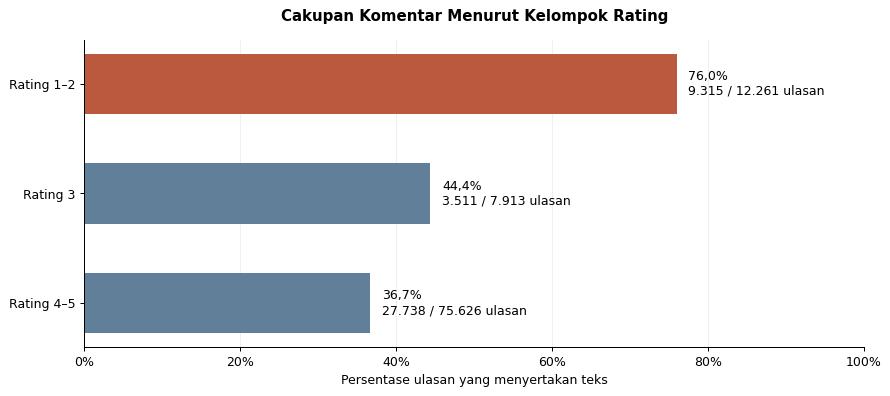

In [ ]:
# Persiapan teks ulasan. Aturan dedup-nya sama dengan tahap 6a (ambil ulasan terbaru
# per order_id), bedanya kali ini kolom teks komentar ikut dibawa, lalu digabung ke
# master table supaya bisa disandingkan dengan status SLA.
import re
from collections import Counter

reviews_urut = df_reviews.sort_values(['order_id', 'review_answer_timestamp', 'review_creation_date'],na_position='first', kind='stable')
reviews_text = reviews_urut.drop_duplicates(subset='order_id', keep='last')
reviews_text = reviews_text[['order_id', 'review_score', 'review_comment_title', 'review_comment_message']]
reviews_text = reviews_text.merge(df_master[['order_id', 'is_late']], on='order_id', how='inner')

reviews_text['teks'] = (reviews_text['review_comment_title'].fillna('') + ' ' + reviews_text['review_comment_message'].fillna('')).str.strip()
df_teks = reviews_text[reviews_text['teks'].str.len() > 0].copy()

# label sentimen pakai proxy skor bintang: 1-2 Negatif, 3 Netral, 4-5 Positif
def label_sentimen(skor):
    if skor <= 2:
        return 'Negatif'
    elif skor == 3:
        return 'Netral'
    return 'Positif'

df_teks['sentimen'] = df_teks['review_score'].apply(label_sentimen)

# Stopword bahasa Portugis disusun manual (tanpa library eksternal).
# Kata negasi (nao/não, nunca, nem) sengaja TIDAK dibuang: kalau "não" ikut terbuang,
# "não recebi o produto" (tidak menerima produk) berubah makna jadi "recebi produto".
STOPWORDS_PT = set("""a o e os as um uma de do da dos das no na nos nas em por para com sem que quem qual quais
ou mas se ao aos à às meu minha meus minhas seu sua seus suas ele ela eles elas eu voce você nós vos lhe lhes
este esta estes estas isso isto aquele aquela já so só foi ser é era são estou está estava estao estão ter tem
têm tinha tive teve há mais menos muito muita muitos muitas pouco pouca bem como quando onde porque pois então
entao ainda até ate depois antes agora sempre também tambem todo toda todos todas outro outra outros outras
mesmo mesma pelo pela pelos pelas num numa vou vai fui ah la lá q pra pro sim ja""".split())

def tokenisasi(teks):
    t = re.sub(r'[^a-zà-ÿ\s]', ' ', teks.lower())
    t = ' ' + t + ' '
    t = t.replace(' nao ', ' não ')   # seragamkan ejaan negasi
    hasil = []
    for w in t.split():
        if (len(w) > 2 or w == 'não') and w not in STOPWORDS_PT:
            hasil.append(w)
    return hasil

def frekuensi_teratas(series_teks, n=15, gram=1):
    c = Counter()
    for t in series_teks:
        token = tokenisasi(t)
        if gram == 1:
            c.update(token)
        else:
            pasangan = []
            for i in range(len(token) - 1):
                pasangan.append(token[i] + ' ' + token[i + 1])
            c.update(pasangan)
    return pd.Series(dict(c.most_common(n)))

n_semua = len(reviews_text)
print(f"Ulasan unik pesanan delivered            : {n_semua:,}")
print(f"Ulasan yang menuliskan teks komentar     : {len(df_teks):,} ({len(df_teks)/n_semua*100:.1f}%)")

# Cakupan komentar menurut kelompok rating
cakupan_base = reviews_text.dropna(subset=['review_score']).copy()

cakupan_base['ada_teks'] = (cakupan_base['teks'].fillna('').str.strip().str.len() > 0)

cakupan_base['kelompok_rating'] = pd.cut(cakupan_base['review_score'],bins=[0, 2, 3, 5],labels=['Rating 1–2', 'Rating 3', 'Rating 4–5'])

cakupan = cakupan_base.groupby('kelompok_rating', observed=True).agg(jumlah_ulasan=('order_id', 'size'), ulasan_berteks=('ada_teks', 'sum'))

cakupan['persen_menulis_teks'] = (100 * cakupan['ulasan_berteks'] / cakupan['jumlah_ulasan'])

print("\nCakupan komentar menurut kelompok rating:")
display(cakupan.round(1))

# Seluruh ulasan terpilih, termasuk yang tidak menyertakan teks
base = reviews_text.copy()

base['ada_teks'] = (base['teks'].fillna('').str.strip().str.len() > 0)

base['kelompok_rating'] = pd.cut(base['review_score'], bins=[0, 2, 3, 5], labels=['Rating 1–2', 'Rating 3', 'Rating 4–5'])

# Penyebut: seluruh ulasan pada kelompok rating yang sama
cakupan = base.groupby('kelompok_rating', observed=True).agg(jumlah_ulasan=('order_id', 'size'), ulasan_berteks=('ada_teks', 'sum'))

cakupan['persen_menulis_teks'] = (cakupan['ulasan_berteks'] / cakupan['jumlah_ulasan'] * 100)

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.barh(cakupan.index.astype(str), cakupan['persen_menulis_teks'], color=['#BB593E', '#617F99', '#617F99'],height=0.55)

for posisi, (_, baris) in enumerate(cakupan.iterrows()):
    persen = f"{baris['persen_menulis_teks']:.1f}%".replace('.', ',')
    jumlah = (
        f"{baris['ulasan_berteks']:,.0f} / "
        f"{baris['jumlah_ulasan']:,.0f} ulasan").replace(',', '.')

    ax.text(baris['persen_menulis_teks'] + 1.5, posisi,f"{persen}\n{jumlah}",va='center',fontsize=10)

ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(PercentFormatter(100, decimals=0))
ax.set_xlabel('Persentase ulasan yang menyertakan teks')
ax.set_title('Cakupan Komentar Menurut Kelompok Rating', fontweight='bold', pad=15)

ax.set_axisbelow(True)
ax.grid(axis='x', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


Insight — Cakupan Komentar dan Bias Partisipasi

Sebanyak 76,0% ulasan dengan rating 1–2 menyertakan teks komentar, dibandingkan 44,4% pada rating 3 dan 36,7% pada rating 4–5. Proporsi penyertaan komentar pada kelompok rating rendah sekitar 2,1 kali proporsi pada kelompok rating tinggi.

Pola ini menunjukkan bahwa ketersediaan komentar tidak merata antarkelompok rating. Kelompok rating rendah lebih terwakili dalam analisis berbasis teks dibandingkan dalam keseluruhan ulasan. Oleh karena itu, frekuensi kata dan tema yang ditemukan perlu ditafsirkan sebagai gambaran ulasan yang menyertakan komentar, bukan langsung sebagai gambaran seluruh pelanggan.

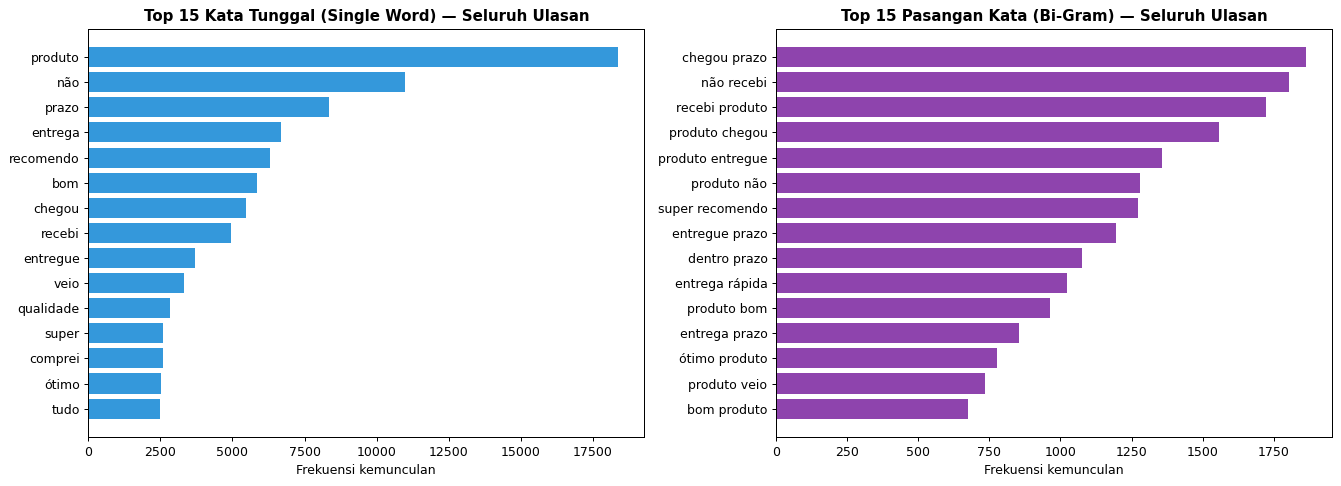

In [ ]:
# visual: top 15 kata tunggal & pasangan kata untuk seluruh ulasan ber-teks
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
uni = frekuensi_teratas(df_teks['teks'], 15, gram=1).sort_values()
bi  = frekuensi_teratas(df_teks['teks'], 15, gram=2).sort_values()
axes[0].barh(uni.index, uni.values, color='#3498db')
axes[0].set_title('Top 15 Kata Tunggal (Single Word) — Seluruh Ulasan', fontsize=12, fontweight='bold')
axes[1].barh(bi.index, bi.values, color='#8e44ad')
axes[1].set_title('Top 15 Pasangan Kata (Bi-Gram) — Seluruh Ulasan', fontsize=12, fontweight='bold')
for ax in axes: ax.set_xlabel('Frekuensi kemunculan')
plt.tight_layout(); plt.show()

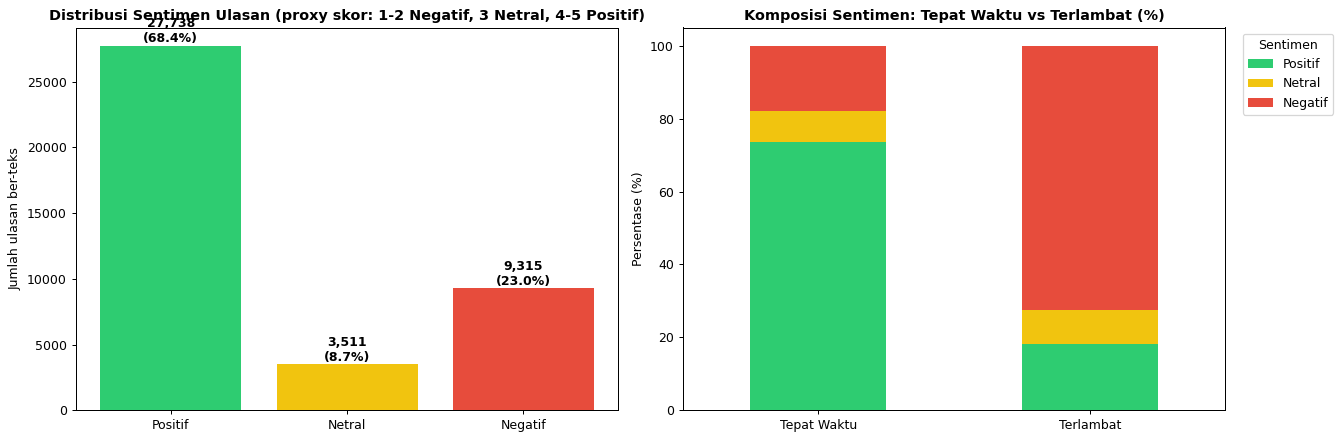

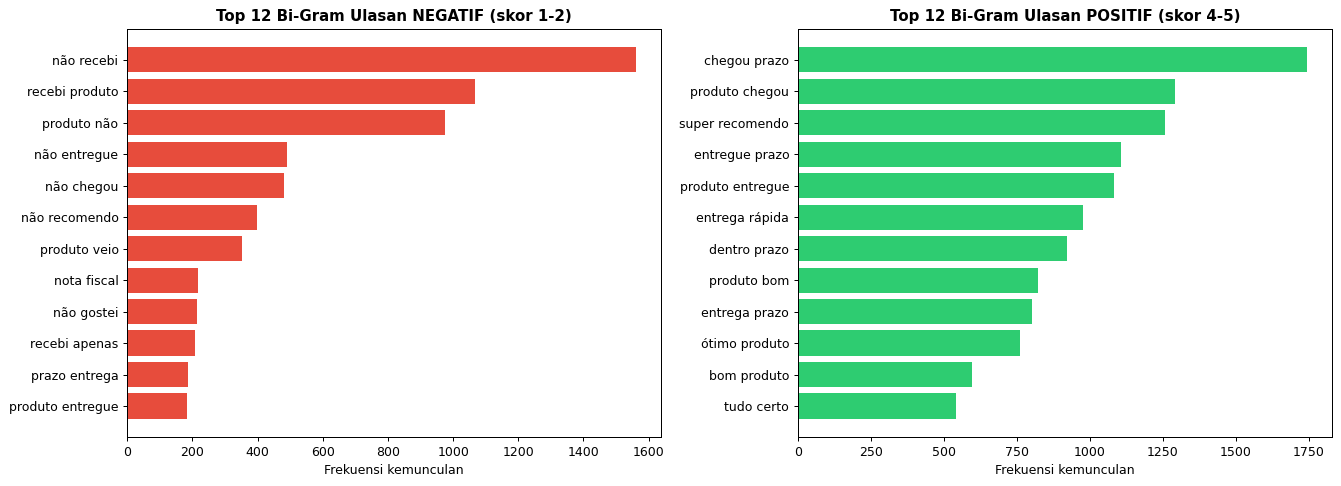

Ulasan negatif yang menyinggung pengiriman/penerimaan barang : 63.6% dari 9,315 ulasan
Ulasan negatif yang memuat frasa 'não recebi' (tidak/belum menerima): 16.0%
Proporsi sentimen NEGATIF | pesanan Tepat Waktu: 17.8%  |  pesanan Terlambat: 72.5%


In [ ]:
# Analisis sentimen: distribusi, kaitannya dengan keterlambatan,
# dan perbandingan bi-gram ulasan Negatif vs Positif
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# grafik 1: distribusi sentimen seluruh ulasan ber-teks
dist_sent = df_teks['sentimen'].value_counts().reindex(['Positif', 'Netral', 'Negatif'])
warna_sent = ['#2ecc71', '#f1c40f', '#e74c3c']
bars = axes[0].bar(dist_sent.index, dist_sent.values, color=warna_sent)
axes[0].set_title('Distribusi Sentimen Ulasan (proxy skor: 1-2 Negatif, 3 Netral, 4-5 Positif)',
                  fontsize=11.5, fontweight='bold')
axes[0].set_ylabel('Jumlah ulasan ber-teks')
for b, v in zip(bars, dist_sent.values):
    axes[0].text(b.get_x() + b.get_width()/2, v + 250, f"{v:,}\n({v/dist_sent.sum()*100:.1f}%)",
                 ha='center', fontweight='bold', fontsize=10)

# grafik 2: komposisi sentimen menurut status SLA
sent_sla = (pd.crosstab(np.where(df_teks['is_late'], 'Terlambat', 'Tepat Waktu'),
                        df_teks['sentimen'], normalize='index') * 100)[['Positif', 'Netral', 'Negatif']]
sent_sla.plot(kind='bar', stacked=True, color=warna_sent, ax=axes[1], rot=0)
axes[1].set_title('Komposisi Sentimen: Tepat Waktu vs Terlambat (%)', fontsize=11.5, fontweight='bold')
axes[1].set_ylabel('Persentase (%)'); axes[1].set_xlabel('')
axes[1].legend(title='Sentimen', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

# perbandingan bi-gram: apa yang dikeluhkan vs apa yang dipuji
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
bi_neg = frekuensi_teratas(df_teks.loc[df_teks['sentimen'] == 'Negatif', 'teks'], 12, gram=2).sort_values()
bi_pos = frekuensi_teratas(df_teks.loc[df_teks['sentimen'] == 'Positif', 'teks'], 12, gram=2).sort_values()
axes[0].barh(bi_neg.index, bi_neg.values, color='#e74c3c')
axes[0].set_title('Top 12 Bi-Gram Ulasan NEGATIF (skor 1-2)', fontsize=12, fontweight='bold')
axes[1].barh(bi_pos.index, bi_pos.values, color='#2ecc71')
axes[1].set_title('Top 12 Bi-Gram Ulasan POSITIF (skor 4-5)', fontsize=12, fontweight='bold')
for ax in axes: ax.set_xlabel('Frekuensi kemunculan')
plt.tight_layout(); plt.show()

# angka pendukung insight
neg = df_teks[df_teks['sentimen'] == 'Negatif']
kw_kirim = neg['teks'].str.lower().str.contains('receb|entreg|prazo|chegou|atras|demor')
print(f"Ulasan negatif yang menyinggung pengiriman/penerimaan barang : {kw_kirim.mean()*100:.1f}% dari {len(neg):,} ulasan")
print(f"Ulasan negatif yang memuat frasa 'não recebi' (tidak/belum menerima): {neg['teks'].str.lower().str.contains('não recebi|nao recebi').mean()*100:.1f}%")
sent_late = pd.crosstab(df_teks['is_late'], df_teks['sentimen'], normalize='index') * 100
print(f"Proporsi sentimen NEGATIF | pesanan Tepat Waktu: {sent_late.loc[False,'Negatif']:.1f}%  |  pesanan Terlambat: {sent_late.loc[True,'Negatif']:.1f}%")

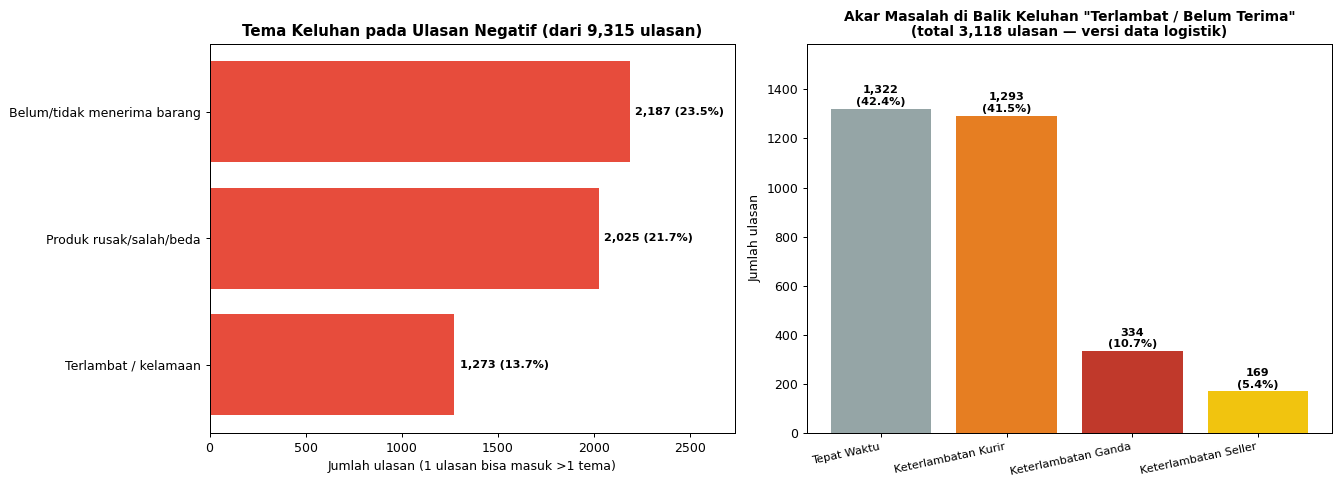

Ulasan negatif yang mengeluh terlambat/belum terima : 3,118 (33.5% dari ulasan negatif)
  (asal angka: 2,187 'belum terima' + 1,273 'terlambat' - 342 ulasan yang menyebut keduanya = total 4 batang grafik kanan)
  - Memang terlambat menurut SLA                    : 1,796 (57.6%), rata-rata meleset 12.5 hari
  - Tercatat TEPAT WAKTU di sistem                  : 1,322 (42.4%), 61.9% di antaranya mengklaim barang belum diterima

Komposisi akar masalah (khusus keluhan yang memang terlambat menurut SLA):


,persen (%)
delay_category,
Keterlambatan Kurir,72.0
Keterlambatan Ganda,18.6
Keterlambatan Seller,9.4


In [ ]:
# Detail lanjutan dari word review: ulasan negatif dikelompokkan per tema keluhan,
# lalu keluhan soal "terlambat / belum terima" dicek silang ke data logistik —
# waktu pelanggan bilang telat, sebenarnya telatnya karena apa?
neg_detail = df_teks[df_teks['sentimen'] == 'Negatif'].copy()
teks_neg = neg_detail['teks'].str.lower()

pola_belum_terima = 'não receb|nao receb|não chegou|nao chegou|não entreg|nao entreg'
pola_terlambat    = 'atras|demor|prazo'
pola_produk       = 'defeito|quebrad|errad|diferente|qualidade|falta'

tema = pd.Series({
    'Belum/tidak menerima barang': teks_neg.str.contains(pola_belum_terima).sum(),
    'Produk rusak/salah/beda'    : teks_neg.str.contains(pola_produk).sum(),
    'Terlambat / kelamaan'       : teks_neg.str.contains(pola_terlambat).sum(),
})

# ambil ulasan yang mengeluh telat ATAU belum terima, gabungkan dengan kategori akar masalah
keluh_telat = neg_detail[teks_neg.str.contains(pola_belum_terima + '|' + pola_terlambat)]
keluh_telat = keluh_telat.merge(df_master[['order_id', 'delay_category', 'delay_days']], on='order_id')

urutan = ['Tepat Waktu', 'Keterlambatan Kurir', 'Keterlambatan Ganda', 'Keterlambatan Seller']
komposisi = keluh_telat['delay_category'].value_counts().reindex(urutan)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# grafik 1: tema keluhan (satu ulasan bisa masuk lebih dari satu tema)
tema_urut = tema.sort_values()
bars = axes[0].barh(tema_urut.index, tema_urut.values, color='#e74c3c')
axes[0].set_title(f'Tema Keluhan pada Ulasan Negatif (dari {len(neg_detail):,} ulasan)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah ulasan (1 ulasan bisa masuk >1 tema)')
axes[0].set_xlim(0, tema.max() * 1.25)
for b in bars:
    axes[0].text(b.get_width() + 30, b.get_y() + b.get_height()/2,
                 f"{b.get_width():,.0f} ({b.get_width()/len(neg_detail)*100:.1f}%)",
                 va='center', fontweight='bold', fontsize=9)

# grafik 2: keluhan "terlambat/belum terima" dicek ke data — akar masalahnya apa?
warna_akar = ['#95a5a6', '#e67e22', '#c0392b', '#f1c40f']
bars = axes[1].bar(urutan, komposisi.values, color=warna_akar)
axes[1].set_title(f'Akar Masalah di Balik Keluhan "Terlambat / Belum Terima"\n(total {komposisi.sum():,} ulasan — versi data logistik)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Jumlah ulasan')
axes[1].set_ylim(0, komposisi.max() * 1.2)
axes[1].set_xticks(range(len(urutan)))
axes[1].set_xticklabels(urutan, rotation=12, ha='right', fontsize=9)
for b, v in zip(bars, komposisi.values):
    axes[1].text(b.get_x() + b.get_width()/2, v + 15, f"{v:,}\n({v/komposisi.sum()*100:.1f}%)",
                 ha='center', fontweight='bold', fontsize=9)
plt.tight_layout(); plt.show()

memang_telat = keluh_telat[keluh_telat['delay_category'] != 'Tepat Waktu']
tercatat_ontime = keluh_telat[keluh_telat['delay_category'] == 'Tepat Waktu']
klaim_belum = neg_detail.loc[neg_detail['order_id'].isin(tercatat_ontime['order_id']),
                             'teks'].str.lower().str.contains(pola_belum_terima)

# asal angka total: gabungan UNIK dua tema pengiriman di grafik kiri
# (ulasan yang menyebut keduanya hanya dihitung sekali) = total 4 batang grafik kanan
overlap_tema = int(tema['Belum/tidak menerima barang'] + tema['Terlambat / kelamaan'] - len(keluh_telat))

print(f"Ulasan negatif yang mengeluh terlambat/belum terima : {len(keluh_telat):,} ({len(keluh_telat)/len(neg_detail)*100:.1f}% dari ulasan negatif)")
print(f"  (asal angka: {int(tema['Belum/tidak menerima barang']):,} 'belum terima' + {int(tema['Terlambat / kelamaan']):,} 'terlambat' - {overlap_tema:,} ulasan yang menyebut keduanya = total 4 batang grafik kanan)")
print(f"  - Memang terlambat menurut SLA                    : {len(memang_telat):,} ({len(memang_telat)/len(keluh_telat)*100:.1f}%), rata-rata meleset {memang_telat['delay_days'].mean():.1f} hari")
print(f"  - Tercatat TEPAT WAKTU di sistem                  : {len(tercatat_ontime):,} ({len(tercatat_ontime)/len(keluh_telat)*100:.1f}%), {klaim_belum.mean()*100:.1f}% di antaranya mengklaim barang belum diterima")
print("\nKomposisi akar masalah (khusus keluhan yang memang terlambat menurut SLA):")
display((memang_telat['delay_category'].value_counts(normalize=True) * 100).round(1).to_frame('persen (%)'))

**Insight & Temuan Kritis (Sesi 1 Lanjutan — Analisis Teks)**
* **[Observasi]:** Dari 95.800 ulasan unik pesanan delivered, **42,3% (40.564 ulasan)** menuliskan teks komentar — dan kecenderungan menulis sangat bias ke arah kekecewaan: **76% ulasan negatif menyertakan teks**, dibandingkan hanya 36,7% pada ulasan positif (pelanggan kecewa jauh lebih vokal). Kosakata teratas didominasi urusan pengiriman: `produto` (produk), `prazo` (tenggat/estimasi), `entrega` (pengiriman), `chegou` (tiba), `recebi` (saya terima). Pada level bi-gram, polanya semakin tajam dan nyaris simetris: pujian #1 pelanggan puas adalah **"chegou (no) prazo" — tiba tepat waktu** (disusul *"entrega rápida"* — pengiriman cepat), sementara keluhan #1 pelanggan kecewa adalah **"não recebi" — saya tidak/belum menerima (produk)**, disusul *"não entregue"* (tidak dikirim) dan *"não chegou"* (tidak sampai). Secara agregat, **63,6% ulasan negatif menyinggung urusan pengiriman/penerimaan barang** dan 16% di antaranya eksplisit memuat frasa *"não recebi"*. Analisis sentimen mengonfirmasi rantai kausal Sesi 1: proporsi sentimen negatif melonjak **4x lipat** — dari **17,8%** (tepat waktu) menjadi **72,5%** (terlambat).
* **[Observasi — detail akar keluhan keterlambatan]:** Pendalaman tema keluhan menunjukkan **3.118 ulasan negatif (33,5%)** secara eksplisit mengeluh *terlambat/belum menerima barang* — angka ini adalah gabungan **unik** dua tema pengiriman pada grafik kiri (2.187 + 1.273 − 342 ulasan yang menyebut keduanya, sehingga hanya dihitung sekali) dan setara dengan total empat batang pada grafik kanan. Saat dicek silang ke data logistik, keluhan ini terbelah menjadi dua akar yang berbeda penanganannya: (1) **57,6% (1.796 ulasan) memang terlambat menurut SLA** — dengan rata-rata meleset **±12,5 hari** dan komposisi tanggung jawab yang konsisten dengan temuan Sesi 2 (**72,0% murni kurir**, 18,6% ganda, 9,4% seller); dan (2) **42,4% (1.322 ulasan) justru tercatat *tepat waktu* di sistem**, padahal **61,9%** di antaranya mengklaim barang belum diterima — bukti kuat adanya masalah **akurasi status *delivered*** (paket ditandai terkirim padahal belum sampai/salah alamat, atau ulasan ditagih terlalu dini).
* **[Hipotesis]:** Suara pelanggan (*Voice of Customer*) selaras penuh dengan temuan kuantitatif: dimensi yang paling menentukan persepsi kualitas layanan Olist adalah **keandalan pengiriman** — persis dimensi *reliability* pada SERVQUAL (Parasuraman et al., 1988). Detail akar keluhan di atas mempertegas bahwa keluhan "terlambat" versi pelanggan bermuara pada **dua masalah operasional sekaligus**: kinerja transit kurir (dominan, ranah VP Operations) dan akurasi pembaruan status *delivered*/momen penagihan ulasan (ranah tim CX) — keduanya layak masuk daftar audit terpisah.

### Sesi 2: Mencari Akar Masalah Keterlambatan (Wilayah vs Seller)

Di sesi ini, kita fokus mencari tahu pihak mana yang paling sering membuat pengiriman menjadi telat. Kita ingin memastikan apakah masalah utamanya ada pada performa kurir di wilayah tertentu, atau justru karena *seller* yang lambat memproses pesanan.

Kita membagi kategori keterlambatan dengan aturan berikut:
* **Kesalahan Seller:** Terjadi jika *seller* baru menyerahkan barang ke kurir melewati batas waktu yang ditentukan (`shipping_limit_date`).
* **Kesalahan Kurir:** Terjadi jika waktu perjalanan paket dari kurir ke tangan pembeli lebih lama dari jatah waktu normalnya.
* **Keterlambatan Ganda:** Terjadi ketika *seller* lambat memproses pesanan, dan kurir juga lambat saat mengantarkannya.

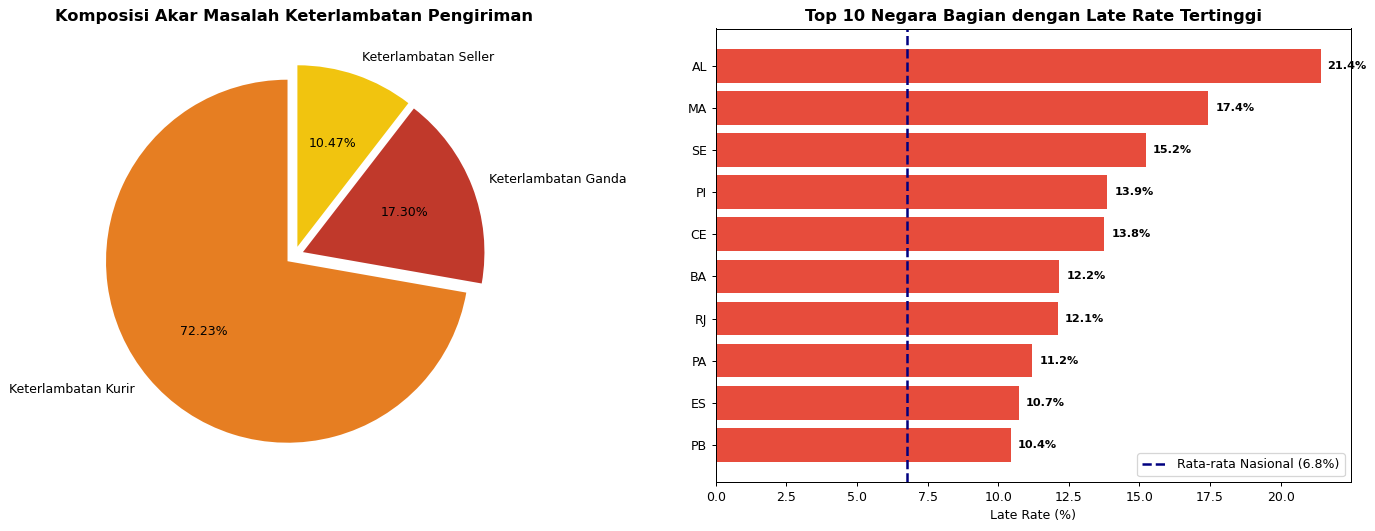

Komposisi tanggung jawab di antara pesanan TERLAMBAT saja:


,persen (%)
delay_category,
Keterlambatan Kurir,72.23
Keterlambatan Ganda,17.30
Keterlambatan Seller,10.47


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# grafik 1: pie chart komposisi akar masalah, khusus pesanan yang terlambat
df_late = df_master[df_master['is_late']]

cat_order = ['Keterlambatan Kurir', 'Keterlambatan Ganda', 'Keterlambatan Seller']
cat_counts = df_late['delay_category'].value_counts().reindex(cat_order)

pie_colors = ['#e67e22', '#c0392b', '#f1c40f']
explode = [0.05, 0.05, 0.05]

axes[0].pie(cat_counts, labels=cat_counts.index, autopct='%1.2f%%',
            colors=pie_colors, explode=explode, startangle=90,
            textprops={'fontsize': 10})
axes[0].set_title('Komposisi Akar Masalah Keterlambatan Pengiriman',
                  fontsize=13, fontweight='bold')

# grafik 2: top 10 negara bagian dengan late rate tertinggi
state_stats = df_master.groupby('customer_state').agg(
    total_orders=('order_id', 'count'), late_rate=('is_late', 'mean')
)
state_stats = state_stats[state_stats['total_orders'] >= 100]   # buang state bervolume sangat kecil biar tidak bias
state_stats = state_stats.sort_values('late_rate', ascending=False)

top10 = (state_stats.head(10)['late_rate'] * 100).sort_values()
bars = axes[1].barh(top10.index, top10.values, color='#e74c3c')
national_rate = df_master['is_late'].mean() * 100
axes[1].axvline(national_rate, color='navy', linestyle='--', linewidth=2,
                label=f'Rata-rata Nasional ({national_rate:.1f}%)')
axes[1].set_title('Top 10 Negara Bagian dengan Late Rate Tertinggi',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Late Rate (%)')
axes[1].legend()
for b in bars:
    axes[1].text(b.get_width() + 0.25, b.get_y() + b.get_height()/2,
                 f"{b.get_width():.1f}%", va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# komposisi tanggung jawab, khusus di antara pesanan terlambat saja
late_only = df_late['delay_category'].value_counts(normalize=True) * 100
print("Komposisi tanggung jawab di antara pesanan TERLAMBAT saja:")
display(late_only.round(2).to_frame('persen (%)'))

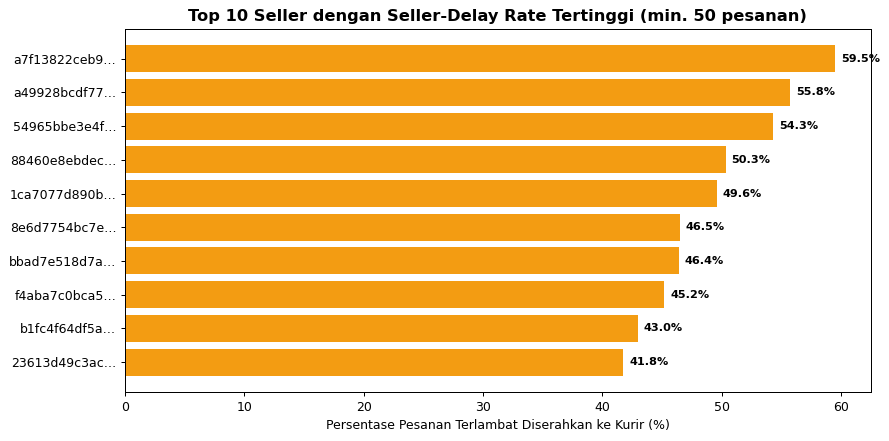

Jumlah seller dengan >= 50 pesanan delivered: 425


In [ ]:
# Analisis tambahan: seller dengan tingkat seller-delay tertinggi (level item)
seller_items = df_order_items.merge(
    df_delivered[['order_id', 'order_delivered_carrier_date']], on='order_id'
)
seller_items['seller_late'] = seller_items['order_delivered_carrier_date'] > seller_items['shipping_limit_date']

seller_perf = seller_items.groupby('seller_id').agg(
    total_orders=('order_id', 'nunique'), seller_late_rate=('seller_late', 'mean')
)
seller_perf = seller_perf[seller_perf['total_orders'] >= 50]   # minimal 50 pesanan biar statistiknya stabil
seller_perf = seller_perf.sort_values('seller_late_rate', ascending=False)

top_sellers = (seller_perf.head(10)['seller_late_rate'] * 100).sort_values()
label_seller = []
for s in top_sellers.index:
    label_seller.append(s[:12] + '…')   # id seller dipotong biar muat di sumbu

plt.figure(figsize=(10, 5))
bars = plt.barh(label_seller, top_sellers.values, color='#f39c12')
plt.title('Top 10 Seller dengan Seller-Delay Rate Tertinggi (min. 50 pesanan)',
          fontsize=13, fontweight='bold')
plt.xlabel('Persentase Pesanan Terlambat Diserahkan ke Kurir (%)')
for b in bars:
    plt.text(b.get_width() + 0.5, b.get_y() + b.get_height()/2,
             f"{b.get_width():.1f}%", va='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Jumlah seller dengan >= 50 pesanan delivered: {len(seller_perf):,}")

### **Insight & Temuan Kritis (Sesi 2)**

* **[Observasi]:**
  * **Analisis Atribusi Tanggung Jawab:** *Baseline* keterlambatan secara nasional tercatat sebesar **6,77%** dari seluruh pesanan berstatus *delivered*. Menariknya, pembagian tanggung jawab menunjukkan ketimpangan yang sangat signifikan: dari total pesanan yang terlambat, **72.23% disebabkan murni oleh kesalahan kurir** (*carrier delay*), **17.30% akibat keterlambatan ganda**, dan hanya **10.47% yang murni karena kelalaian *seller***. Temuan ini membuktikan bahwa *seller* UMKM pada umumnya cukup disiplin dalam menyerahkan barang, sehingga *bottleneck* utama operasional berada pada **fase transit ekspedisi**.
  * **Analisis Geografis & Volume:** Secara geografis, permasalahan ini terakumulasi di wilayah **Timur Laut Brasil**. Alagoas (AL) mencatat *late rate* tertinggi mencapai **21,4%** (lebih dari 3 kali lipat rata-rata nasional), disusul oleh Maranhão (MA) sebesar **17,4%**, dan Sergipe (SE) sebesar **15,2%**. Selain itu, Rio de Janeiro (RJ) menjadi *red flag* tersendiri dengan *late rate* sebesar **12,1%**. Meski persentasenya tidak setinggi wilayah Timur Laut, volume pesanan di RJ sangat masif yaitu mencapai **12.350 pesanan**, sehingga dampak terhadap total keterlambatan nasional menjadi sangat besar.
  * **Evaluasi Performa *Seller*:** Di sisi lain, analisis kinerja menunjukkan adanya segelintir *seller* bervolume besar yang memiliki *seller-delay rate* hingga **50–60%**, sehingga layak dimasukkan ke dalam daftar pembinaan prioritas.

* **[Hipotesis]:**
  Tingginya kesenjangan performa antarwilayah ini sejalan dengan kondisi geografis Brasil. Hub konsolidasi Olist terpusat di wilayah Selatan dan Tenggara, sehingga jarak pengiriman ke wilayah Timur Laut menjadi sangat jauh. Di saat yang sama, standar SLA estimasi pengiriman belum dikalibrasi secara akurat untuk rute-rute jauh tersebut. Oleh karena itu, intervensi yang paling efektif adalah melakukan **evaluasi mitra ekspedisi berbasis koridor wilayah**, alih-alih memberikan sanksi atau penalti secara pukul rata kepada seluruh *seller*.

---

*Untuk memastikan bahwa keterkaitan antara lokasi wilayah dan tingkat keterlambatan ini signifikan secara statistik (serta bukan merupakan variasi acak), selanjutnya kita melakukan uji Chi-Square.*

### Uji Hipotesis Sesi 2 (Chi-Square Test of Independence)

Karena kedua variabel bersifat **kategorikal** (`customer_state` berisi 27 kategori wilayah dan `is_late` berupa *True/False*), uji yang tepat adalah **Chi-Square Test of Independence**.

**Rumusan Hipotesis:**
* $H_0$: Tidak ada hubungan yang signifikan antara wilayah pengiriman (*customer_state*) dengan status keterlambatan pesanan.
* $H_1$: Terdapat hubungan yang signifikan antara wilayah pengiriman (*customer_state*) dengan status keterlambatan pesanan.

Tingkat signifikansi ($\alpha$) ditetapkan sebesar **0.05**.

In [ ]:
from scipy.stats import chi2_contingency

contingency_state = pd.crosstab(df_master['customer_state'], df_master['is_late'])
print("Tabel Kontingensi (5 baris pertama):")
display(contingency_state.head())

chi2_stat, p_val, dof, expected = chi2_contingency(contingency_state)

print("-" * 55)
print(f"Nilai Chi-Square   : {chi2_stat:.4f}")
print(f"P-value            : {p_val:.4e}")
print(f"Degrees of Freedom : {dof}")
print("-" * 55)

alpha = 0.05
print("\nKesimpulan Uji Statistik:")
if p_val < alpha:
    print("Tolak H0: Terdapat hubungan yang signifikan antara wilayah pengiriman dengan status keterlambatan.")
else:
    print("Gagal Tolak H0: Tidak terdapat hubungan yang signifikan antara wilayah dengan keterlambatan.")

Tabel Kontingensi (5 baris pertama):


is_late,False,True
customer_state,,
AC,77,3
AL,312,85
AM,141,4
AP,65,2
BA,2860,396


-------------------------------------------------------
Nilai Chi-Square   : 1785.7617
P-value            : 0.0000e+00
Degrees of Freedom : 26
-------------------------------------------------------

Kesimpulan Uji Statistik:
Tolak H0: Terdapat hubungan yang signifikan antara wilayah pengiriman dengan status keterlambatan.


### **Interpretasi & Validasi Hipotesis (Sesi 2)**

Berdasarkan hasil uji statistik, diperoleh nilai **Chi-Square ≈ 1.785,8** dengan **p-value ≈ 0,0000** ($p < 0,05$), sehingga keputusannya adalah **Menolak $H_0$**.

Hal ini membuktikan secara signifikan bahwa tingkat keterlambatan pengiriman **tidak terdistribusi merata antarwilayah**. Dengan kata lain, risiko terjadinya keterlambatan sangat **bergantung pada negara bagian tujuan**.

Temuan statistik ini memvalidasi bahwa intervensi operasional logistik tidak boleh dilakukan secara acak (*blind spot*) atau dipukul rata secara nasional. Prioritas perbaikan dan alokasi sumber daya harus difokuskan pada wilayah dengan tingkat keterlambatan tertinggi, yaitu koridor **Timur Laut (AL, MA, SE, PI, CE, BA)** serta wilayah bervolume tinggi seperti **Rio de Janeiro (RJ)**.

### Sesi 3: Analisis GMV & Retensi Pelanggan (Cohort Analysis)

Di sesi ini, kita fokus mengukur seberapa sehat struktur pendapatan bisnis Olist dan melihat bagaimana tingkat retensi pembeli dari waktu ke waktu. Kita ingin mengetahui seberapa besar perbedaan kontribusi GMV antara pembeli sekali belanja (*one-time buyer*) dengan pembeli yang loyal (*repeat buyer*).

Agar pelacakan riwayat belanja pelanggan akurat dan tidak keliru, kita menggunakan ketentuan berikut:
* **Identifikasi Pelanggan:** Identitas pelanggan dilacak menggunakan `customer_unique_id`, bukan `customer_id` biasa (yang merupakan *session ID* sekali pakai), sehingga riwayat transaksi pembeli yang sama dapat terdeteksi dengan tepat.
* **Klasifikasi Pembeli:** Pelanggan dengan total transaksi 1 kali dikategorikan sebagai *One-Time Buyer*, sedangkan pelanggan dengan total transaksi lebih dari 1 kali dikategorikan sebagai *Repeat Buyer*.
* **Perhitungan GMV:** Nilai GMV dihitung murni dari harga barang (`price`) untuk melihat pendapatan riil platform, tanpa mencampur biaya ongkir (`freight_value`).

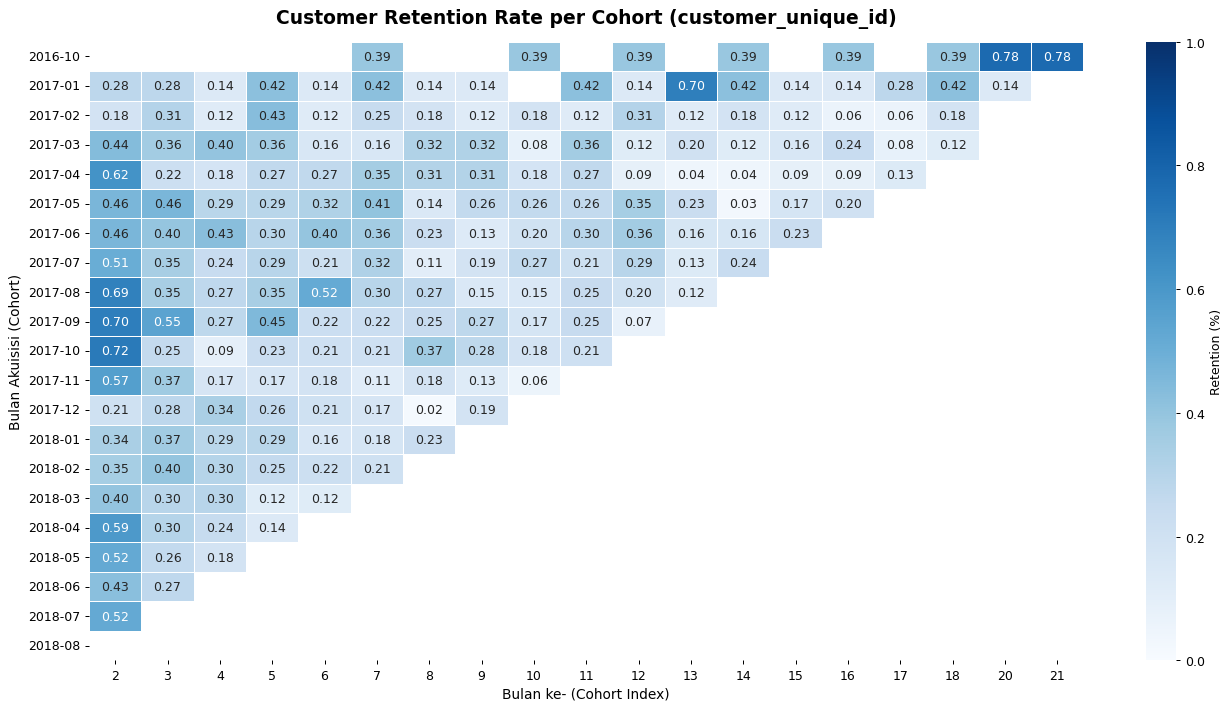

Rata-rata retensi bulan ke-2 seluruh cohort: 0.47%


In [ ]:
# Cohort analysis (retention rate)

# 1. cohort month = bulan transaksi PERTAMA setiap pelanggan unik
df_master['cohort_month'] = (
    df_master.groupby('customer_unique_id')['order_purchase_timestamp']
    .transform('min').dt.to_period('M')
)

# 2. cohort index = jarak bulan sejak akuisisi (1 = bulan akuisisi)
df_master['cohort_index'] = (
    (df_master['order_month'] - df_master['cohort_month']).apply(lambda x: x.n) + 1   # .n = selisih bulan dalam angka
)

# 3. jumlah pelanggan unik aktif per cohort & index
cohort_data = (
    df_master.groupby(['cohort_month', 'cohort_index'])['customer_unique_id']
    .nunique().reset_index()
)
cohort_counts = cohort_data.pivot(index='cohort_month', columns='cohort_index',
                                  values='customer_unique_id')

# 4. retention rate; cohort mungil (<100 pelanggan, akhir 2016) disaring agar heatmap tidak bias
cohort_counts = cohort_counts[cohort_counts[1] >= 100]
retention = cohort_counts.divide(cohort_counts[1], axis=0)

# 5. heatmap (bulan akuisisi disembunyikan supaya gradasi bulan 2+ kelihatan)
plt.figure(figsize=(15, 8))
plt.title('Customer Retention Rate per Cohort (customer_unique_id)',
          fontsize=15, fontweight='bold', pad=15)
sns.heatmap(retention.iloc[:, 1:] * 100, annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1.0, linewidths=0.8, linecolor='white',
            cbar_kws={'label': 'Retention (%)'})
plt.ylabel('Bulan Akuisisi (Cohort)', fontsize=11)
plt.xlabel('Bulan ke- (Cohort Index)', fontsize=11)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

avg_m2 = retention[2].mean() * 100
print(f"Rata-rata retensi bulan ke-2 seluruh cohort: {avg_m2:.2f}%")

,jumlah_pelanggan,total_gmv,avg_gmv_per_pelanggan,pct_pelanggan,pct_gmv
segment,,,,,
One-Time Buyer,90531,12488921.27,137.95,97.0,94.5
Repeat Buyer,2798,727389.92,259.97,3.0,5.5


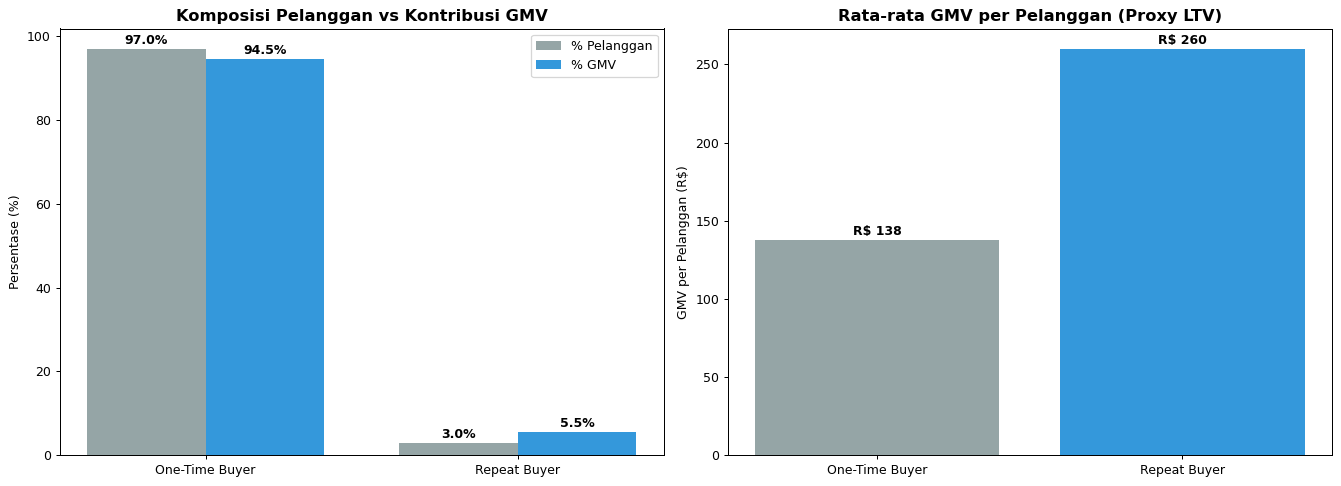

In [ ]:
# Kontribusi GMV: one-time vs repeat buyer
user_stats = (
    df_master.groupby('customer_unique_id')
    .agg(total_orders=('order_id', 'nunique'), total_gmv=('order_gmv', 'sum'))
    .reset_index()
)
user_stats['segment'] = np.where(user_stats['total_orders'] > 1,
                                 'Repeat Buyer', 'One-Time Buyer')

seg = user_stats.groupby('segment').agg(
    jumlah_pelanggan=('customer_unique_id', 'count'),
    total_gmv=('total_gmv', 'sum'),
    avg_gmv_per_pelanggan=('total_gmv', 'mean')
)
seg['pct_pelanggan'] = seg['jumlah_pelanggan'] / seg['jumlah_pelanggan'].sum() * 100
seg['pct_gmv'] = seg['total_gmv'] / seg['total_gmv'].sum() * 100
display(seg.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
seg_plot = seg.reindex(['One-Time Buyer', 'Repeat Buyer'])
bar_colors = ['#95a5a6', '#3498db']

# grafik 1: komposisi pelanggan & GMV
x = np.arange(2)
w = 0.38
axes[0].bar(x - w/2, seg_plot['pct_pelanggan'], w, label='% Pelanggan', color='#95a5a6')
axes[0].bar(x + w/2, seg_plot['pct_gmv'], w, label='% GMV', color='#3498db')
axes[0].set_xticks(x); axes[0].set_xticklabels(seg_plot.index)
axes[0].set_title('Komposisi Pelanggan vs Kontribusi GMV', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Persentase (%)'); axes[0].legend()
for i, (pu, pg) in enumerate(zip(seg_plot['pct_pelanggan'], seg_plot['pct_gmv'])):
    axes[0].text(i - w/2, pu + 1.2, f"{pu:.1f}%", ha='center', fontweight='bold')
    axes[0].text(i + w/2, pg + 1.2, f"{pg:.1f}%", ha='center', fontweight='bold')

# grafik 2: rata-rata GMV per pelanggan (proxy LTV)
bars = axes[1].bar(seg_plot.index, seg_plot['avg_gmv_per_pelanggan'], color=bar_colors)
axes[1].set_title('Rata-rata GMV per Pelanggan (Proxy LTV)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('GMV per Pelanggan (R$)')
for b in bars:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 3,
                 f"R$ {b.get_height():,.0f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### **Insight & Temuan Kritis (Sesi 3)**

* **[Observasi]:**
  * **Krisis Retensi Pelanggan:** Kondisi retensi Olist berada pada level **krisis akut**. Dari total **93.329 pelanggan unik**, hanya **3,0% (2.798 pelanggan)** yang pernah melakukan transaksi ulang (repeat buyer). Visualisasi heatmap cohort mengonfirmasi pola ini secara konsisten di seluruh periode akuisisi, di mana retensi pada bulan kedua (indeks ke-2) hanya berkisar antara **0,18%–0,72%**. Artinya, lebih dari 99% pelanggan langsung menghilang sebulan setelah melakukan transaksi pertama.
  * **Dampak terhadap GMV:** Rendahnya retensi ini berdampak langsung pada struktur pendapatan bisnis. Dari total GMV sebesar **Rial 13,22 Juta (R$ 13,22 Juta)**, kontribusi dari repeat buyer hanya sebesar **5,5%**, sedangkan **94,5% GMV** masih sepenuhnya ditopang oleh one-time buyer.
  * **Potensi Nilai Pelanggan (LTV):** Meski porsinya kecil, data menunjukkan sinyal peluang yang sangat kuat: rata-rata GMV per pelanggan repeat buyer mencapai **Rial 260**, atau sekitar **1,9 kali lipat** lebih tinggi dibandingkan rata-rata GMV one-time buyer (**Rial 138**).

* **[Hipotesis]:**
  Ketergantungan pada one-time buyer menciptakan model pertumbuhan bisnis yang sangat rapuh, karena Olist harus terus mengeluarkan biaya akuisisi (CAC) untuk menggantikan pelanggan yang churn. Padahal, biaya mempertahankan pelanggan jauh lebih efisien dibandingkan mencari pelanggan baru. Selisih LTV sebesar 1,9 kali lipat ini membuktikan bahwa setiap pelanggan yang berhasil dipertahankan bernilai hampir dua kali lipat bagi platform. Temuan ini memvalidasi pentingnya pergeseran fokus strategi perusahaan, dari yang semula sekadar mengejar pertumbuhan (growth-driven) menjadi menjaga keberlanjutan profit (profitability-driven).

---

*Sebagai langkah penutup, kita menguji rantai kausal utama dalam analisis ini: apakah **pengalaman keterlambatan pada pesanan pertama** berpengaruh secara signifikan terhadap keputusan pelanggan untuk belanja kembali (repeat) atau berhenti (churn)?*

### Uji Hipotesis Sesi 3 (Chi-Square Test of Independence)

Karena kedua variabel bersifat **kategorikal** (pengalaman pesanan pertama *Terlambat/Tepat Waktu* dan status akhir pelanggan *Repeat/Churn*), digunakan **Chi-Square Test of Independence**.

**Rumusan Hipotesis:**
* $H_0$: Tidak ada hubungan yang signifikan antara pengalaman keterlambatan pada pesanan pertama dengan keputusan pelanggan menjadi *repeat buyer*.
* $H_1$: Terdapat hubungan yang signifikan antara pengalaman keterlambatan pada pesanan pertama dengan keputusan pelanggan menjadi *repeat buyer*.

Tingkat signifikansi ($\alpha$) ditetapkan sebesar **0.05**.

In [ ]:
from scipy.stats import chi2_contingency

# Pengalaman PESANAN PERTAMA setiap pelanggan unik
first_order = (
    df_master.sort_values('order_purchase_timestamp')
    .drop_duplicates('customer_unique_id', keep='first')
    [['customer_unique_id', 'is_late']]
    .rename(columns={'is_late': 'first_order_late'})
)
user_exp = user_stats.merge(first_order, on='customer_unique_id', validate='one_to_one')
user_exp['is_repeat'] = user_exp['total_orders'] > 1

# Perbandingan deskriptif tingkat repeat
repeat_rate = user_exp.groupby('first_order_late')['is_repeat'].mean() * 100
print("Tingkat repeat order berdasarkan pengalaman pesanan pertama:")
print(f"  Pesanan pertama Tepat Waktu : {repeat_rate.get(False, 0):.2f}% repeat")
print(f"  Pesanan pertama Terlambat   : {repeat_rate.get(True, 0):.2f}% repeat\n")

contingency_repeat = pd.crosstab(user_exp['first_order_late'], user_exp['is_repeat'])
print("Tabel Kontingensi:")
display(contingency_repeat)

chi2_stat, p_val, dof, expected = chi2_contingency(contingency_repeat)
print("-" * 55)
print(f"Nilai Chi-Square   : {chi2_stat:.4f}")
print(f"P-value            : {p_val:.4f}")
print(f"Degrees of Freedom : {dof}")
print("-" * 55)

alpha = 0.05
print("\nKesimpulan Uji Statistik:")
if p_val < alpha:
    print("Tolak H0: Terdapat hubungan yang signifikan antara keterlambatan pesanan pertama dengan keputusan repeat order.")
else:
    print("Gagal Tolak H0: Tidak terdapat hubungan yang signifikan.")

Tingkat repeat order berdasarkan pengalaman pesanan pertama:
  Pesanan pertama Tepat Waktu : 3.04% repeat
  Pesanan pertama Terlambat   : 2.49% repeat

Tabel Kontingensi:


is_repeat,False,True
first_order_late,,
False,84337,2640
True,6194,158


-------------------------------------------------------
Nilai Chi-Square   : 5.9233
P-value            : 0.0149
Degrees of Freedom : 1
-------------------------------------------------------

Kesimpulan Uji Statistik:
Tolak H0: Terdapat hubungan yang signifikan antara keterlambatan pesanan pertama dengan keputusan repeat order.


### **Interpretasi & Validasi Hipotesis (Sesi 3)**

Berdasarkan hasil uji statistik, diperoleh nilai **Chi-Square ≈ 5,92** dengan **p-value ≈ 0,0149** (p < 0,05), sehingga keputusannya adalah **Menolak H0**.

Secara statistik terbukti ada hubungan signifikan antara pengalaman keterlambatan pada pesanan pertama dengan keputusan pelanggan untuk belanja kembali. Tingkat *repeat order* pelanggan yang pesanannya tepat waktu berada di angka **3,04%**, namun angka ini anjlok menjadi **2,49%** jika pesanan pertamanya terlambat. Ini mencerminkan penurunan relatif sebesar **±18%** dari basis retensi yang memang sudah tipis.

Keterlambatan terbukti merusak kepuasan, dan kepuasan yang hancur pada *first impression* akan menutup peluang konversi pelanggan menjadi pembeli loyal. Mengingat nilai LTV *repeat buyer* mencapai 1,9 kali lipat, kehilangan ±18% peluang *repeat order* akibat keterlambatan pengiriman adalah bentuk kebocoran nilai bisnis yang sangat nyata bagi Olist.

### Sesi 4 (Analisis Tambahan): Tren Bulanan & Deteksi Periode Krisis Logistik

Analisis tambahan ini melengkapi pemetaan *bottleneck*: apakah keterlambatan bersifat konstan sepanjang waktu, atau ada **periode krisis** tertentu yang menjadi episentrum masalah? Temuan ini penting untuk perencanaan kapasitas (*capacity planning*) VP Operations.

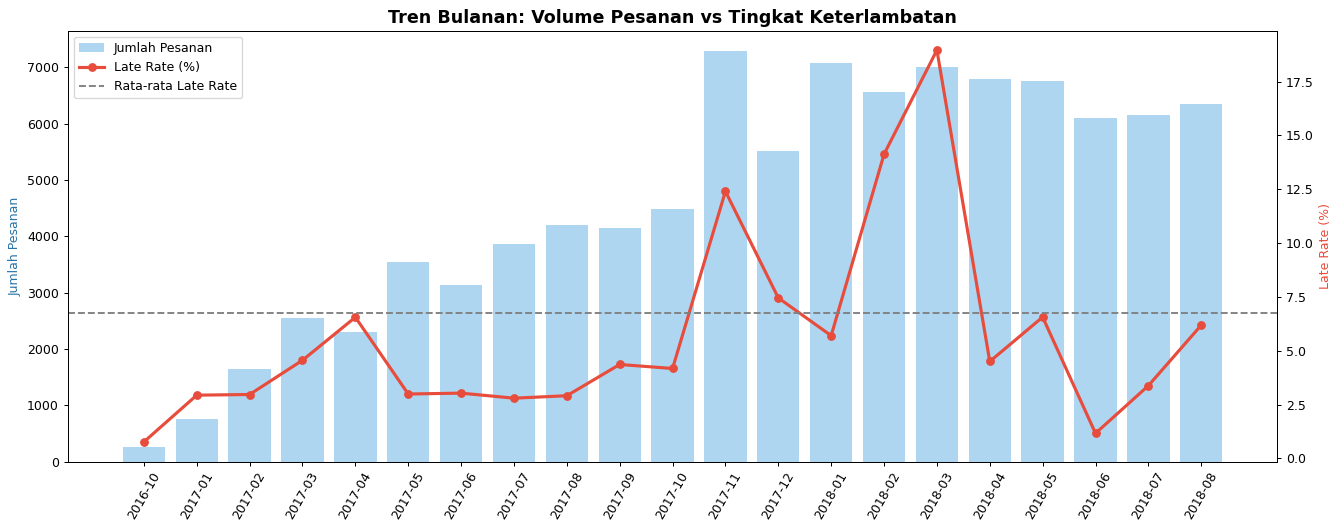

4 bulan dengan late rate tertinggi (%):


,late_rate (%)
order_month,
2018-03,18.96
2018-02,14.13
2017-11,12.40
2017-12,7.46


In [ ]:
# Catatan: seluruh blok grafik ini harus berada dalam SATU cell dan dijalankan utuh.
# Judul & legend sengaja dipasang langsung ke objek fig/ax1 (bukan plt.title / state global),
# supaya kalau notebook dijalankan ulang dari atas grafik tetap muncul lengkap.
monthly = df_master.groupby('order_month').agg(
    total_orders=('order_id', 'count'), late_rate=('is_late', 'mean'),
    gmv=('order_gmv', 'sum')
)
monthly = monthly[monthly['total_orders'] >= 100]   # buang bulan bervolume sangat kecil (awal 2016 & bulan terakhir yang belum lengkap)
monthly.index = monthly.index.astype(str)

fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.bar(monthly.index, monthly['total_orders'], color='#aed6f1', label='Jumlah Pesanan')
ax1.set_ylabel('Jumlah Pesanan', color='#2874a6')
ax1.tick_params(axis='x', rotation=60)

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['late_rate'] * 100, color='#e74c3c',
         marker='o', linewidth=2.5, label='Late Rate (%)')
ax2.axhline(df_master['is_late'].mean() * 100, color='gray', linestyle='--',
            label='Rata-rata Late Rate')
ax2.set_ylabel('Late Rate (%)', color='#e74c3c')

ax1.set_title('Tren Bulanan: Volume Pesanan vs Tingkat Keterlambatan',
              fontsize=14, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
fig.tight_layout()
plt.show()

krisis = (monthly['late_rate'] * 100).sort_values(ascending=False).head(4).round(2)
print("4 bulan dengan late rate tertinggi (%):")
display(krisis.to_frame('late_rate (%)'))

**Insight & Temuan Kritis (Sesi 4)**
* **[Observasi]:** Keterlambatan **bersifat fluktuatif** — terdapat dua episode krisis yang jelas: (1) **November 2017** (*late rate* melonjak ke **12,4%**) bertepatan dengan periode Black Friday. dan (2) **Februari–Maret 2018** yang menjadi puncak krisis dengan *late rate* **14,1%** dan **19,0%** — hampir 3x rata-rata. Sebaliknya, Juni 2018 membuktikan sistem *mampu* berkinerja baik (*late rate* hanya 1,2%) pada volume serupa.
* **[Hipotesis]:** Pola ini mengindikasikan bahwa sistem logistik mungkin mengalami tekanan ketika volume pesanan meningkat, karena pada beberapa periode lonjakan volume diikuti peningkatan late rate: Jaringan ekspedisi kolaps saat volume melonjak (musim belanja akhir tahun) dan kondisi cuaca pada awal 2018 dapat menjadi konteks yang perlu ditelusuri, tetapi belum dapat dinyatakan sebagai penyebab langsung *(periode yang bertepatan dengan cuaca buruk musim hujan Brasil dan pemulihan pasca *peak season*).* Karena Juni 2018 terbukti bisa mencapai 1,2%, target proyek menekan keterlambatan minimal 15% (dari **baseline *late-rate* 6,77%** menjadi ≤5,75%) **realistis** — kuncinya adalah fokus pada manajemen kapasitas bulan-bulan puncak (pada periode berisiko tinggi), bukan perombakan total sistem.

## Kesimpulan

Merujuk kembali pada masalah utama — *penurunan ketepatan waktu pengiriman berdampak pada kepuasan pelanggan, menyebabkan churn, dan berimbas pada hilangnya potensi GMV* — seluruh rantai tersebut kini telah terbukti secara empiris, dengan setiap ***Masalah Turunan #N dijawab oleh Tujuan #N**):*

1. **Keterlambatan berdampak signifikan pada penurunan skor ulasan yang:**
- Dari 96.446 pesanan delivered yang valid dengan *baseline* keterlambatan berada di angka 6,77%,  **rata-rata keterlambatan mencapai jumlah yang parah  sebanyak ±10,6 hari** melewati estimasi waktu tiba. Dampaknya pada skor ulasan, dramatis: Skor ulasan anjlok dari **4,29 menjadi 2,27** (drop 2,02 poin), dan proporsi ulasan **bintang 1 melonjak 8x lipat** (6,6% → 53,8%).
- **Uji Independent T-Test (t ≈ 100,8; p < 0,05) memvalidasi** bahwa penuruan kepuasan ini signifikan secara statistik, bukan kebetulan.
- Analisis teks ulasan dari sisi *Voice of Customer*, menangkap: #1 Ulasan sentimen Positif adalah **"chegou no prazo"** (tiba tepat waktu), dan #1 Ulasan sentimen Negatif adalah **"não recebi"** (tidak/belum menerima produk), **sebanyak 63,6% menyinggung urusan pengiriman**. Proporsi sentimen Negatif melonjak 4x lipat (17,8% → 72,5%) saat pesanan terlambat.
2. **Bottleneck Terkonsentrasi di Kurir & Wilayah Timur Laut:**
- Atribusi tanggung jawab menunjukkan **±72% keterlambatan murni kesalahan fase transit kurir**, ±17% keterlambatan ganda, dan sekitar 10% masuk kategori keterlambatan seller.
- Secara geografis, **uji Chi-Square (χ² ≈ 1.785,8; p < 0,05) memvalidasi** bahwa keterlambatan bergantung pada wilayah di Timur Laut Brasil (AL 21,4%, MA 17,4%, SE 15,2%) ditambah volume raksasa RJ (12,1% dari 12.350 pesanan).
3. ***One-time* buyer penyumbang terbesar nilai GMV, namun GMV per *repeat-buyer* lebih tinggi, keterlambatan pada pesanan pertama berhubungan signifikan dengan penurunan retensi:**
- Dari 93.329 pelanggan unik, hanya sekitar 3,0% yang melakukan repeat order, **sementara 97,0% hanya melakukan satu transaksi.** Cohort analysis menunjukkan retensi bulan ke-2 hanya sekitar **0,2–0,7%**. Akibatnya, 94,5% dari **GMV R13,22 Juta ditopang *one-time buyer*** (Model pertumbuhan rapuh yang terus bergantung pada CAC mahal). **Sedangkan rata-rata GMV per repeat buyer sekitar R260,** dibandingkan R138 pada one-time buyer.
- **Uji Chi-Square (χ² ≈ 5,92; p = 0,0149) memvalidasi** bahwa pengalaman keterlambatan di pesanan pertama berhubungan signifikan dengan gagalnya konversi menjadi pelanggan loyal (tingkat *repeat* turun ±18% relatif, dari 3,04% ke 2,49%).
4. **Pola Periode Keterlambatan bersifat fluktuatif:**
- Analisis tren bulanan menunjukkan pola yang tidak konstan/bersifat fluktuatif. **Puncaknya terjadi pada Maret 2018 (18,96%), Februari 2018 (14,13%), dan November 2017 (12,40%), sedangkan Desember 2017 (7,46%)** di atas rata-rata ***Late rate* pada angka 6,77%,** sedangkan pada Juni 2018 hanya 1,2%. Temuan ini menunjukkan bahwa faktor waktu/periode operasional perlu diperhitungkan dalam monitoring dan perencanaan kapasitas logistik.

## Rekomendasi

#### 1. **VP Operations & Logistics — Prioritaskan ekspedisi dan periode berisiko**
- **Fokuskan perbaikan pada AL, MA, SE, PI, CE, BA dan RJ** — koridor Timur Laut dengan *late rate* 2–3x rata-rata nasional plus jalur bervolume raksasa RJ — karena **±72% keterlambatan terbukti berasal dari fase transit kurir, bukan seller**.
- **Lakukan audit performa mitra dan evaluasi/renegosiasi SLA per koridor sebelum periode volume tinggi.** Susun rencana kapasitas musiman (armada & hub cadangan) untuk periode November–Maret, karena data membuktikan sistem kolaps saat lonjakan volume (*late rate* 12–19%) namun mampu mencapai 1,2% di bulan normal — bukti target tercapai tanpa merombak total sistem.
- **SMART:**
  - Mulai bulan 1–2: Audit performa ekspedisi pada 7 wilayah prioritas.
  - Bulan 3–4: Evaluasi/renegosiasi SLA dengan mitra pada koridor bermasalah (rampung **sebelum *peak season* November**).
  - Bulan 5–12: Monitoring *late rate* bulanan per wilayah, evaluasi kuartalan.
  - Sebelum periode November–Maret: Lakukan review kapasitas dan rencana mitigasi.
  - **Target/KPI: Turunkan late rate dari 6,77% → ≤5,75% atau minimal 15% relatif, dalam 12 bulan.**

#### 2. **Head of Customer Experience (CX) — Lindungi pelanggan pada first order yang terlambat dengan sistem kompensasi proaktif**
- **Buat pilot kompensasi** yang fokus pada pelanggan baru yang mengalami keterlambatan pada pesanan pertama. Ketika pesanan terdeteksi melewati estimasi (durasi transit sudah melebihi jatah), **kirim notifikasi permintaan maaf + *voucher* diskon sebelum pelanggan komplain.**
- **Prioritaskan pesanan pertama pelanggan baru** — karena data membuktikan keterlambatan di pesanan pertama menurunkan peluang *repeat order* **±18% relatif (3,04% → 2,49%)** dan **53,8% pesanan terlambat berujung bintang 1**.
- **Arahkan anggaran retensi secara tertarget berbasis temuan Sesi 3:** *voucher* pembelian kedua bagi pelanggan baru yang transaksinya masih hangat, dan **kampanye *win-back*** bagi pelanggan yang pernah mengalami keterlambatan — karena LTV *repeat buyer* terbukti **1,9x lipat** *one-time buyer* (R$ 260 vs R$ 138), setiap konversi bernilai hampir dua kali lipat. *Voucher* ini sekaligus instrumen *win-back* untuk mendongkrak retensi menuju target +5% (HBR, 2014: kenaikan retensi 5% = profitabilitas naik 25–95%).
- **Audit pula akurasi status *delivered***: keluhan teks #1 pelanggan adalah *"não recebi"* (merasa belum menerima barang saat diminta mengulas), dan cek silang Sesi 1 Lanjutan membuktikan **42,4% keluhan "terlambat/belum terima" justru tercatat tepat waktu di sistem** (61,9%-nya mengklaim barang belum diterima) — indikasi paket ditandai terkirim padahal belum sampai/salah alamat, atau ulasan ditagih terlalu dini.
- **SMART:**
  - Mulai bulan 3, setelah mekanisme deteksi keterlambatan disiapkan; *voucher* kompensasi terkirim **≤ H+1** sejak keterlambatan terdeteksi.
  - Bulan 3–4: Pilot selama 2 bulan.
  - Target cakupan: 100% pelanggan baru yang memenuhi kriteria pilot menerima notifikasi; *voucher* hanya diberikan pada kasus yang melewati *threshold* yang ditentukan.
  - Bulan 5: Evaluasi hasil pilot.
  - Bulan 6–12: Lanjutkan hanya jika terdapat peningkatan KPI; kampanye *win-back* pelanggan yang pernah terlambat berjalan mulai kuartal pertama.
  - **Target/KPI: Repeat rate 3,00% → ≥3,15% (naik 5% relatif) dalam 12 bulan.**

#### 3. **Seller Management — Cukup melakukan pembinaan tertarget seller yang benar-benar bermasalah**
- Fokus pada segelintir seller bervolume ≥50 pesanan dengan *seller-delay rate* ekstrem (50–60%) **melalui edukasi operasional** dan, **bila tidak membaik, penalti bertahap.** Mayoritas seller terbukti disiplin (hanya ±10% keterlambatan murni akibat seller), sehingga energi tim lebih efisien dialokasikan ke daftar prioritas ini.
- **SMART:**
  - Mulai bulan 1: Berikan laporan performa kepada 10 seller tersebut.
  - Bulan 2–3: Coaching/edukasi operasional.
  - Bulan 4: Ukur kembali *seller-delay rate*. Seller yang belum membaik → masuk monitoring lanjutan.
  - **Target/KPI: Penurunan seller-delay rate minimal 15% relatif pada seller prioritas.**

#### 4. **VP Operations & Logistics — Terapkan *Seasonal Capacity Planning* pada bulan berisiko**
- **Gunakan pola historis** untuk membuat *seasonal capacity plan,* **sehingga perusahaan melakukan persiapan sebelum periode risiko,** bukan setelah keterlambatan melonjak. Lakukan review kebutuhan kapasitas dan koordinasi dengan partner ekspedisi sebelum periode **November–Maret; jika kapasitas diperkirakan tidak mencukupi, siapkan alternatif alokasi/kapasitas tambahan.**
- **SMART:**
  - Mulai Bulan 2 sebelum periode risiko: Identifikasi wilayah berisiko dan konfirmasi kapasitas partner ekspedisi.
  - Bulan 1 sebelum periode risiko: Koordinasikan kebutuhan kapasitas tambahan dengan mitra ekspedisi pada wilayah prioritas. Jika kapasitas tidak cukup, minta kapasitas tambahan atau lakukan penyesuaian alokasi pengiriman.
  - Bulan 0 (periode risiko): Monitor *late rate* mingguan secara berkala dan lakukan eskalasi jika *late rate* meningkat di atas target.
  - Bulan 1 setelah periode risiko: Evaluasi dan bandingkan late rate aktual dengan baseline 6,77%.
  - **Target/KPI: Penurunan *late rate* minimal 15% relatif, dari baseline 6,77% → ≤5,75%, dengan evaluasi bulanan.**

#### 5. **Manajemen (Strategis) — Geser strategi dari *growth-driven* menuju *profitability-driven***
- Validasi kuantitatif telah lengkap untuk menggeser strategi: dengan **94,5% GMV bertumpu pada *one-time buyer*** (model pertumbuhan rapuh yang terus bergantung pada CAC mahal) dan LTV *repeat buyer* 1,9x lebih tinggi, **setiap 1% perbaikan retensi bernilai jauh lebih murah daripada akuisisi setara (CAC 5–25x biaya retensi).**
- Perbaikan logistik pada rekomendasi #1–#4 adalah **prasyarat** strategi retensi ini — memperbaiki pengalaman pengiriman berarti menambal kebocoran di hulu sebelum anggaran loyalitas digelontorkan.
- **SMART:**
  - Kuartal 1: Jalankan prasyarat (rekomendasi #1–#4) dan pilot CX.
  - Mulai kuartal 2: Keputusan realokasi bertahap anggaran akuisisi → retensi, berbasis hasil evaluasi pilot.
  - Review per kuartal dengan KPI gabungan: *late rate*, *repeat rate*, dan porsi GMV dari *repeat buyer*.
  - **Target/KPI: Porsi GMV repeat buyer naik bertahap dari baseline 5,5%, seiring repeat rate menuju ≥3,15%.**

### Target Terukur — Metode SMART (Perhitungan Data Internal + Dukungan Data Sekunder)

Dua target utama proyek dioperasionalkan dengan kerangka **SMART** berikut. Seluruh angka internal dihitung langsung dari master table (96.446 pesanan delivered; 93.329 pelanggan unik; GMV R$ 13,22 Juta; periode data ±25 bulan).

| Komponen | Target 1 — Menekan Keterlambatan Pengiriman | Target 2 — Menaikkan Retensi (*Repeat Order*) |
| :--- | :--- | :--- |
| **S — Specific** | Menurunkan *late rate* minimal **15% (relatif)**: dari *baseline* **6,77% → ≤ 5,75%**, difokuskan pada koridor Timur Laut (AL, MA, SE, PI, CE, BA) + RJ dan bulan puncak November–Maret (temuan Sesi 2 & 4). | Menaikkan *repeat rate* **5% (relatif)**: dari **3,00% → ≥ 3,15%**, melalui kompensasi proaktif + program retensi tertarget — voucher pembelian kedua untuk pelanggan baru & kampanye *win-back* untuk pelanggan yang pernah terlambat (temuan Sesi 3). |
| **M — Measurable (perhitungan data internal)** | KPI: *late rate* bulanan per wilayah. Dari 96.446 pesanan delivered dengan total GMV ±R$13,22 juta, penurunan late rate dari 6,77% → 5,75% berarti **penurunan 1,02 poin persentase, atau sekitar ±980 pesanan terlambat lebih sedikit.** | KPI: *repeat rate* dan retensi bulan ke-2 per cohort. Repeat rate ditargetkan meningkat 5% relatif, dari 3,00% menjadi ≥3,15%. Keberhasilan retensi diukur melalui persentase customer yang melakukan pembelian kedua pada bulan ke-2 setelah first purchase. Repeat buyer saat ini berkontribusi 5,5% GMV, **dengan rata-rata GMV Rp259,97, hampir 1,9x lebih tinggi dibanding one-time buyer (Rp137,95).** |
| **A — Achievable** | **Internal:** sistem terbukti pernah mencapai *late rate* **1,2% (Juni 2018)** pada volume serupa, dan ±72% *delay* terkonsentrasi di fase kurir — intervensi cukup menyasar mitra ekspedisi & kapasitas musiman, tanpa merombak seluruh sistem. | **Internal:** sasaran konversinya jelas dan bernilai — LTV *repeat buyer* 1,9x lipat (R$ 260 vs R$ 138) — dan kenaikan 0,15 poin adalah langkah kecil yang realistis dari basis 3,00%. **Sekunder:** 84% konsumen enggan kembali setelah satu pengalaman kirim buruk (Convey, 2021) — artinya perbaikan pengalaman kirim (Target 1) secara langsung membuka ruang naiknya retensi. |
| **R — Relevant** | Keterlambatan terbukti penghancur utama kepuasan: skor 4,29 → 2,27 (T-Test p < 0,05), 72,5% ulasan pesanan terlambat bersentimen negatif, keluhan teks #1 *"não recebi"*. **Sekunder:** ketepatan waktu = dimensi *reliability*, faktor utama persepsi kualitas layanan (SERVQUAL — Parasuraman, Zeithaml & Berry, 1988); terbukti pula pada dataset yang sama oleh Praxedes & Oliveira Filho (2025). | 94,5% GMV bertumpu *one-time buyer* (model rapuh) dan keterlambatan pesanan pertama memangkas peluang *repeat* ±18% relatif (Chi-Square p = 0,0149). **Sekunder:** kenaikan retensi 5% mendongkrak profit 25–95% dan CAC 5–25x lebih mahal daripada biaya retensi (Harvard Business Review, 2014 — merujuk riset Bain & Company/Frederick Reichheld). |
| **T — Time-bound** | **12 bulan** dengan evaluasi kuartalan; renegosiasi SLA ekspedisi & rencana kapasitas rampung **sebelum peak season November**. | **12 bulan** dengan evaluasi kuartalan; voucher kompensasi terkirim **≤ H+1** sejak keterlambatan terdeteksi; kampanye *win-back* pelanggan yang pernah terlambat berjalan mulai kuartal pertama. |

**Sumber data sekunder yang dirujuk:** Harvard Business Review (2014) — *The Value of Keeping the Right Customers*, merujuk riset Bain & Company/Frederick Reichheld; Convey (2021) — riset konsumen *last-mile delivery*; Parasuraman, Zeithaml & Berry (1988) — SERVQUAL; Praxedes & Oliveira Filho (2025) — studi pada dataset Olist yang sama.

### Ringkasan Eksekusi per Stakeholder

| Stakeholder | Action | Waktu | Scope | KPI | Target |
|---|---|---|---|---|---|
| **Operations & Logistics** | Audit performa & SLA partner ekspedisi; evaluasi koridor/wilayah bermasalah | **M1–M4** | Prioritas **AL, MA, SE, PI, CE, BA + RJ** | *Late rate* per wilayah/partner | **6,77% → ≤5,75%** |
| **Customer Experience (CX)** | Pilot notifikasi keterlambatan + kompensasi/voucher untuk pelanggan yang terdampak | **M3–M5 pilot**, evaluasi M5 | **First-order customer** yang terdeteksi berisiko terlambat | Repeat rate + coverage pilot | **3,00% → 3,15%** |
| **Seller Management** | Coaching seller bermasalah; evaluasi ulang setelah coaching | **M1–M4** | **Top 10 seller**, ≥50 order, *seller-delay rate* tertinggi | *Seller-delay rate* | **Turun ≥15% relatif** |
| **Operations & Logistics** | **Seasonal capacity planning** sebelum periode risiko + monitoring saat periode berlangsung | **M-2 → M+1 tiap periode risiko**, dengan persiapan khusus sebelum **Nov–Mar** | Periode/wilayah dengan risiko *late rate* tinggi | *Late rate* bulanan/periode | **6,77% → ≤5,75%** |
| **Manajemen (Strategis)** | Realokasi bertahap anggaran akuisisi → retensi setelah pilot CX terbukti | **Mulai kuartal 2**, review per kuartal | Strategi *growth-driven* → *profitability-driven* | Porsi GMV *repeat buyer* & *repeat rate* | **Naik bertahap dari 5,5% / 3,00%** |

### Cost-Benefit Analysis — Estimasi Dampak Bisnis (*Business Impact*)

Bagian ini menerjemahkan dua target SMART di atas menjadi estimasi dampak bisnis. Seluruh angka **manfaat** dihitung langsung dari master table; dataset tidak memuat biaya operasional logistik, sehingga **data biaya operasional tidak tersedia, estimasi biaya menggunakan asumsi** yang dapat disesuaikan saat evaluasi. Fokusnya adalah hubungan keterlambatan → kepuasan pelanggan → retensi → GMV. Target 1 berfokus pada kepuasan pelanggan, sedangkan Target 2 pada retensi dan GMV, sehingga manfaat tidak dihitung dua kali.

**Target 1 — Menekan *late rate* 6,77% → ≤5,75% (dampak pada kepuasan & reputasi)**

| Komponen | Estimasi | Dasar Perhitungan |
|---|---|---|
| Manfaat: pesanan terlambat dicegah | **±984 pesanan** per periode data | Penurunan 1,02 poin persentase × 96.446 pesanan delivered |
| Manfaat: skor ulasan terlindungi | Setiap pesanan dicegah luput dari *drop* **4,29 → 2,27** (−2,02 poin) | Rata-rata skor pesanan tepat waktu vs terlambat (Sesi 1, T-Test p < 0,05) |
| Manfaat: ulasan bintang 1 dicegah | **±529 ulasan** | 53,8% pesanan terlambat berujung bintang 1 × 984 pesanan |
| Nilai yang dipertaruhkan (*value at risk*) | **R$ 986 ribu (7,5% total GMV)** terpapar risiko *churn* | Total order_gmv dari pesanan yang mengalami keterlambatan dibandingkan dengan total GMV delivered |
| Biaya | Jam kerja tim ops (audit & renegosiasi SLA) + sewa armada/hub cadangan Nov–Maret | Asumsi: intervensi bersifat kontraktual & manajerial, estimasi biaya operasional; data biaya aktual tidak tersedia di dataset |

**Kelayakan:** Target 1 adalah **investasi hulu** — Target 1 berfokus pada perbaikan kualitas pengiriman dan kepuasan pelanggan. Dampak finansialnya tidak dihitung sebagai GMV tambahan langsung, tetapi sebagai **GMV yang berada dalam risiko akibat keterlambatan. Dari data, sekitar R$986 ribu GMV (7,46% dari total GMV)** berasal dari pesanan yang terlambat. Perbaikan pengiriman diharapkan membantu menjaga pengalaman pelanggan dan mengurangi risiko pelanggan tidak melakukan pembelian ulang. Karena mayoritas keterlambatan berasal dari fase kurir, perbaikan dapat difokuskan pada mitra ekspedisi dan kapasitas saat peak season, tanpa perlu perubahan besar pada sistem.

**Target 2 — Pilot kompensasi proaktif CX (*repeat rate* 3,00% → ≥3,15%)**

| Komponen | Estimasi | Dasar Perhitungan / Asumsi |
|---|---|---|
| Populasi sasaran | **6.352 pelanggan** per periode data | Pelanggan yang pesanan *pertamanya* terlambat (dari master table) |
| Biaya voucher | **±R 21,9 ribu** | Asumsi pilot: nilai voucher 10% AOV (rata-rata GMV per pelanggan one-time) ≈ R 13,80, *redemption rate* 25% → 1.588 voucher terpakai |
| Manfaat langsung: GMV transaksi kedua terpicu | **±R 219 ribu** | 1.588 transaksi penebusan × AOV *one-time buyer* R 138 |
| Potensi tambahan GMV | **+R 17 ribu GMV** | +140 pelanggan tambahan menjadi repeat × selisih rata-rata GMV repeat vs one-time R$ 122 (R 260 − R 138) |
| Potensi jangka panjang (*benchmark* HBR +5 pp) | **±4.666 pelanggan repeat ≈ +R 569 ribu GMV** | Skenario retensi 3,00% → 8,00% |

**Kelayakan:** rasio GMV-terpicu terhadap biaya diskon ≈ **9x**. Karena voucher berbentuk diskon *pembelian kedua*, biaya baru keluar ketika pendapatan baru benar-benar masuk (*self-funding*) — risiko bisnisnya rendah, dan *break-even* tercapai selama margin kontribusi transaksi kedua melebihi nilai diskon R$ 15.

**Catatan asumsi:** nilai voucher (10% AOV) dan *redemption rate* (25%) adalah parameter pilot yang dikalibrasi ulang pada evaluasi bulan ke-5; seluruh angka populasi, AOV, LTV, dan GMV berasal dari data internal.